## Conditional Volatility Models: Pre-Crisis

This notebook models the **conditional volatility of daily changes in the Bank of England 10-year nominal zero-coupon gilt yield**.

The conditional-mean and conditional-volatility problems are kept separate. A common **AR(2) conditional mean** is used to construct innovations, and the same innovations are then modelled using:

- ARCH
- GARCH
- EGARCH
- GJR-GARCH
- TARCH

The notebook uses the same chronological pre-crisis design as Notebook 03:

- crisis start: **23 September 2022**;
- final 60 pre-crisis market observations: validation sample;
- all earlier pre-crisis observations: training sample;
- final no-crisis volatility model: refit using all information through **22 September 2022**;
- volatility forecast begins on **23 September 2022**;
- no crisis observation is fed back into the fixed-origin no-crisis volatility forecast.

Volatility is latent, so forecast evaluation uses squared conditional-mean innovations as a realised-variance proxy. QLIKE is the primary volatility loss function, with variance MAE/RMSE and volatility-scale MAE/RMSE also reported.

#### Validation and Final Refit Strategy

The final 60 pre-crisis observations, from 29 June to 22 September 2022, are first withheld from estimation and used as an out-of-sample validation period to compare the volatility models. 

After model evaluation is complete, the models are refitted using the full pre-crisis sample through 22 September, including those 60 observations, because they would have been known by the final pre-crisis forecast origin.

The resulting models are then used to generate fixed-origin volatility forecasts from 23 September onward without incorporating any crisis-period observations.

### Conditional-Volatility Models

After fitting the conditional-mean model, the remaining innovation is written as

$$
\varepsilon_t = \sigma_t z_t,
$$

where:

- $\varepsilon_t$ is the residual from the conditional-mean model;
- $\sigma_t$ is the conditional volatility at time $t$;
- $z_t$ is the standardised innovation, assumed to have mean zero and variance one.

The purpose of ARCH-family models is to model how $\sigma_t^2$, the conditional variance of the residuals, changes through time.

#### 1. ARCH

The **Autoregressive Conditional Heteroskedasticity (ARCH)** model allows current volatility to depend on previous squared residuals.

An ARCH(\(p\)) model is

$$
\sigma_t^2 =
\omega
+
\sum_{i=1}^{p}\alpha_i\varepsilon_{t-i}^2.
$$

For example, ARCH(1) is

$$
\sigma_t^2 =
\omega+\alpha_1\varepsilon_{t-1}^2.
$$

A large shock yesterday, whether positive or negative, increases today's predicted variance because the residual is squared.

**What ARCH adds:** it replaces the assumption of constant residual variance with a variance that changes according to past shocks.



#### 2. GARCH

The **Generalised ARCH (GARCH)** model extends ARCH by allowing volatility to depend on both:

1. past squared residuals; and
2. past conditional variance.

A GARCH(1,1) model is

$$
\sigma_t^2 =
\omega
+
\alpha_1\varepsilon_{t-1}^2
+
\beta_1\sigma_{t-1}^2.
$$

Here:

- $\alpha_1$ measures the response to the most recent shock;
- $\beta_1$ measures volatility persistence.

**What GARCH adds to ARCH:** ARCH only remembers past shocks, whereas GARCH also remembers previous volatility. This allows volatility shocks to persist for longer periods without requiring many ARCH lags.



#### 3. EGARCH

The **Exponential GARCH (EGARCH)** model extends GARCH by allowing positive and negative shocks to have different effects on volatility.

A common EGARCH(1,1,1) specification is

$$
\log(\sigma_t^2) =
\omega
+
\beta_1\log(\sigma_{t-1}^2)
+
\alpha_1
\left(
|z_{t-1}|-E|z_{t-1}|
\right)
+
\gamma_1 z_{t-1},
$$

where

$$
z_{t-1} =
\frac{\varepsilon_{t-1}}
{\sigma_{t-1}}.
$$

The $\gamma_1$ parameter captures **asymmetry**: it allows positive and negative innovations of the same magnitude to affect future volatility differently.

Because EGARCH models the **log of variance**, the predicted variance is automatically positive.

**What EGARCH adds to GARCH:** it introduces asymmetric responses to positive and negative shocks and models log-variance rather than variance directly.



#### 4. GJR-GARCH

The **GJR-GARCH** model also introduces asymmetry, but does so by adding an indicator variable to the standard GARCH equation.

For GJR-GARCH(1,1,1),

$$
\sigma_t^2 =
\omega
+
\alpha_1\varepsilon_{t-1}^2
+
\gamma_1
I(\varepsilon_{t-1}<0)
\varepsilon_{t-1}^2
+
\beta_1\sigma_{t-1}^2,
$$

where

$$
I(\varepsilon_{t-1}<0)
=
\begin{cases}
1, & \varepsilon_{t-1}<0,\\
0, & \varepsilon_{t-1}\geq0.
\end{cases}
$$

Therefore:

- a positive innovation has an effect approximately equal to $\alpha_1$;
- a negative innovation has an effect approximately equal to $\alpha_1+\gamma_1$.

**What GJR-GARCH adds to GARCH:** it explicitly allows negative and positive innovations to have different effects on future variance.



#### 5. TARCH

The **Threshold ARCH (TARCH/ZARCH)** model is another asymmetric volatility model. In the specification used here, it models the conditional volatility using the **absolute size** of previous innovations rather than their squared size.

A TARCH(1,1,1) specification can be written as

$$
\sigma_t =
\omega
+
\alpha_1|\varepsilon_{t-1}|
+
\gamma_1
I(\varepsilon_{t-1}<0)
|\varepsilon_{t-1}|
+
\beta_1\sigma_{t-1}.
$$

The threshold term $\gamma_1$ allows negative and positive innovations of equal magnitude to affect volatility differently.

**What TARCH adds:** like GJR-GARCH, it captures asymmetric responses, but the `power=1` TARCH specification used in this analysis models the effect of the **absolute innovation** rather than the squared innovation.



#### How the Models Build on Each Other

| Model | Past shocks | Past volatility | Asymmetric shocks | Main extension |
|---|---|---|---|---|
| **ARCH** | Squared residuals | No | No | Introduces time-varying variance |
| **GARCH** | Squared residuals | Yes | No | Adds persistence through past variance |
| **EGARCH** | Standardised shocks | Yes | Yes | Models log-variance and asymmetric responses |
| **GJR-GARCH** | Squared residuals | Yes | Yes | Adds a threshold for negative innovations |
| **TARCH** | Absolute residuals | Yes | Yes | Threshold asymmetry using absolute shock magnitude |


- ARCH --> **past shocks predict current volatility**.
- GARCH --> **past volatility predicts current volatility**.
- EGARCH, GJR-GARCH and TARCH then allow the **sign of a shock** to matter as well as its magnitude.

### Install and import packages

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("arch") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "arch"
    ])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 929.8/929.8 kB 17.7 MB/s  0:00:00


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import jarque_bera
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX

from arch import arch_model

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

SEED = 42
np.random.seed(SEED)

### Load the processed BoE dataset

In [3]:
DATA_PATH = Path("data") / "processed" / "boe_10y_zero_coupon_clean.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Processed dataset not found. Run Notebook 01 first so that "
        "data/processed/boe_10y_zero_coupon_clean.csv is created."
    )

boe = pd.read_csv(
    DATA_PATH,
    parse_dates=["date"]
)

required_columns = {"date", "yield_10y"}

if not required_columns.issubset(boe.columns):
    raise ValueError(
        f"Expected columns {required_columns}, but found {set(boe.columns)}"
    )

boe = (
    boe
    .sort_values("date")
    .drop_duplicates(subset="date", keep="first")
    .reset_index(drop=True)
)

boe["yield_10y"] = pd.to_numeric(
    boe["yield_10y"],
    errors="coerce"
)

boe = boe.dropna(
    subset=["date", "yield_10y"]
).reset_index(drop=True)

print(f"Loaded: {DATA_PATH}")
print(f"Observations: {len(boe)}")
print(
    f"Date range: "
    f"{boe['date'].min().date()} to {boe['date'].max().date()}"
)

boe.head()

Loaded: data/processed/boe_10y_zero_coupon_clean.csv
Observations: 2779
Date range: 2014-01-02 to 2024-12-31


,date,yield_10y,date_raw,yield_raw
0,2014-01-02,3.1625,02 Jan 14,3.1625
1,2014-01-03,3.1579,03 Jan 14,3.1579
2,2014-01-06,3.1053,06 Jan 14,3.1053
3,2014-01-07,3.0831,07 Jan 14,3.0831
4,2014-01-08,3.1140,08 Jan 14,3.1140


### Create the modelling series

The yield is measured in percentage points. Daily changes are converted to basis points:

$$
\Delta y_t^{bps}=100(y_t-y_{t-1}).
$$

The volatility models are fitted to innovations measured in basis points.

In [4]:
model_data = boe[["date", "yield_10y"]].copy()

model_data["yield_change"] = (
    model_data["yield_10y"].diff()
)

model_data["yield_change_bps"] = (
    model_data["yield_change"] * 100
)

model_data.head()

,date,yield_10y,yield_change,yield_change_bps
0,2014-01-02,3.1625,NaN,NaN
1,2014-01-03,3.1579,-0.0046,-0.46
2,2014-01-06,3.1053,-0.0526,-5.26
3,2014-01-07,3.0831,-0.0222,-2.22
4,2014-01-08,3.1140,0.0309,3.09


### Pre-crisis training and validation split

The split exactly follows the information restriction used in Notebook 03.

The final 60 observations before 23 September 2022 are retained for pre-crisis forecast validation. No crisis observation enters model selection or validation.

In [5]:
CRISIS_START = pd.Timestamp("2022-09-23")
COUNTERFACTUAL_END = pd.Timestamp("2022-10-31")
VALIDATION_SIZE = 60

pre_crisis = (
    model_data.loc[
        model_data["date"] < CRISIS_START
    ]
    .copy()
    .reset_index(drop=True)
)

if VALIDATION_SIZE >= len(pre_crisis) - 100:
    raise ValueError(
        "VALIDATION_SIZE is too large for the pre-crisis sample."
    )

train_level = (
    pre_crisis.iloc[:-VALIDATION_SIZE]
    .copy()
    .reset_index(drop=True)
)

test_level = (
    pre_crisis.iloc[-VALIDATION_SIZE:]
    .copy()
    .reset_index(drop=True)
)

train_changes = (
    train_level["yield_change_bps"]
    .dropna()
    .astype(float)
    .copy()
)

test_changes = (
    test_level["yield_change_bps"]
    .astype(float)
    .copy()
)

HORIZON = len(test_level)

counterfactual_window = (
    model_data.loc[
        (model_data["date"] >= CRISIS_START)
        & (model_data["date"] <= COUNTERFACTUAL_END)
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Pre-crisis observations: {len(pre_crisis)}")
print(f"Training observations: {len(train_level)}")
print(f"Validation observations: {len(test_level)}")
print(f"Training end: {train_level['date'].max().date()}")
print(f"Validation start: {test_level['date'].min().date()}")
print(f"Validation end: {test_level['date'].max().date()}")
print(f"Final pre-crisis date: {pre_crisis['date'].max().date()}")
print(
    "No-crisis volatility window:",
    counterfactual_window["date"].min().date(),
    "to",
    counterfactual_window["date"].max().date()
)

Pre-crisis observations: 2205
Training observations: 2145
Validation observations: 60
Training end: 2022-06-28
Validation start: 2022-06-29
Validation end: 2022-09-22
Final pre-crisis date: 2022-09-22
No-crisis volatility window: 2022-09-23 to 2022-10-31


### ARCH/GARCH Modelling Pipeline

- **Fit a conditional-mean model first**, such as AR(2), to explain the predictable part of the yield changes.

- **Calculate the residuals** $ \varepsilon_t $, which are the differences between the actual and predicted yield changes.

- **Check the residuals for autocorrelation**. Ideally, the residuals themselves should have little remaining autocorrelation.

- **Check the squared residuals** $\varepsilon_t^2 $ using the ACF and an ARCH-LM test. Autocorrelation in the squared residuals indicates that the variance changes over time and that volatility clustering may be present.

- If ARCH effects are present, fit a conditional-volatility model:
  - **ARCH** models current variance using past squared residuals.
  - **GARCH** models current variance using both past squared residuals and past conditional variances.

- **Check the standardised residuals** $ \varepsilon_t / \sigma_t $ after fitting the volatility model. A well-specified model should leave standardised residuals with little autocorrelation and little remaining ARCH structure.

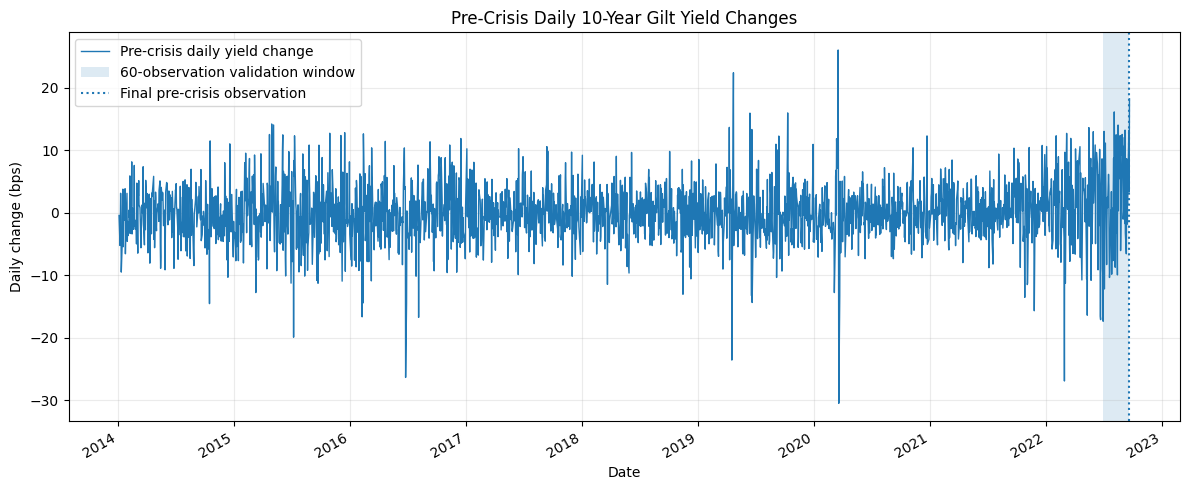

In [6]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    pre_crisis["date"],
    pre_crisis["yield_change_bps"],
    linewidth=1,
    label="Pre-crisis daily yield change"
)

ax.axvspan(
    test_level["date"].min(),
    test_level["date"].max(),
    alpha=0.15,
    label="60-observation validation window"
)

ax.axvline(
    pd.Timestamp("2022-09-22"),
    linestyle=":",
    linewidth=1.5,
    label="Final pre-crisis observation"
)

ax.set_title("Pre-Crisis Daily 10-Year Gilt Yield Changes")
ax.set_xlabel("Date")
ax.set_ylabel("Daily change (bps)")
ax.grid(alpha=0.25)
ax.legend()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Pre-Crisis Training and Validation Split

The pre-crisis sample contains 2,205 observations ending on 22 September 2022. The first 2,145 observations are used for model estimation, while the final 60 market observations, from 29 June to 22 September, are reserved for out-of-sample volatility validation. 

After validation, the selected volatility models are refitted using the full pre-crisis information set and used to generate a fixed-origin no-crisis volatility forecast from 23 September onward without incorporating any crisis observations.

### Common conditional-mean specification

Notebook 03 selected **AR(2)** within the autoregressive family using pre-crisis training information. A single common AR(2) mean is used here so that differences across ARCH-family models are attributable to the conditional-variance specification rather than to different mean models.

For daily changes $x_t$,

$$
x_t=c+\phi_1x_{t-1}+\phi_2x_{t-2}+\varepsilon_t.
$$

The volatility models are fitted to the resulting innovations $\varepsilon_t$.

In [7]:
MEAN_AR_ORDER = 2

def fit_mean_model(change_series):
    change_series = (
        pd.Series(change_series)
        .dropna()
        .astype(float)
    )

    fit = SARIMAX(
        change_series,
        order=(MEAN_AR_ORDER, 0, 0),
        trend="c",
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    residuals = (
        pd.Series(
            np.asarray(fit.resid, dtype=float),
            index=change_series.index
        )
        .iloc[MEAN_AR_ORDER:]
        .dropna()
    )

    return fit, residuals


train_mean_fit, train_innovations = fit_mean_model(
    train_changes
)

print(train_mean_fit.summary())

                               SARIMAX Results                                
Dep. Variable:       yield_change_bps   No. Observations:                 2144
Model:               SARIMAX(2, 0, 0)   Log Likelihood               -6334.812
Date:                Sat, 29 Aug 2026   AIC                          12677.624
Time:                        20:34:12   BIC                          12700.302
Sample:                             0   HQIC                         12685.923
                               - 2144                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0319      0.102     -0.313      0.754      -0.231       0.168
ar.L1         -0.0352      0.016     -2.200      0.028      -0.066      -0.004
ar.L2         -0.0438      0.017     -2.637      0.0

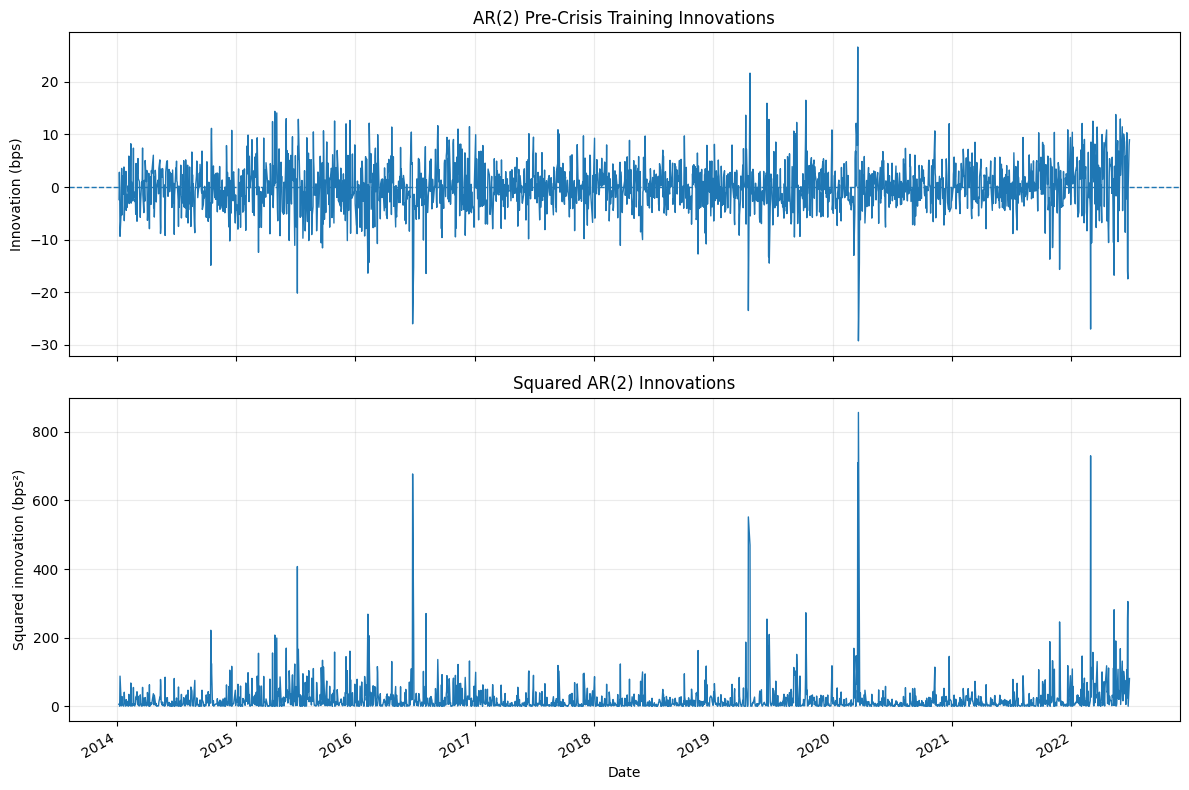

In [8]:
fig, axes = plt.subplots(
    2, 1,
    figsize=(12, 8)
)

axes[0].plot(
    train_level.loc[
        train_innovations.index,
        "date"
    ],
    train_innovations,
    linewidth=1
)

axes[0].axhline(
    0,
    linewidth=1,
    linestyle="--"
)

axes[0].set_title(
    "AR(2) Pre-Crisis Training Innovations"
)
axes[0].set_ylabel("Innovation (bps)")
axes[0].grid(alpha=0.25)

axes[1].plot(
    train_level.loc[
        train_innovations.index,
        "date"
    ],
    train_innovations.pow(2),
    linewidth=1
)

axes[1].set_title(
    "Squared AR(2) Innovations"
)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Squared innovation (bps²)")
axes[1].grid(alpha=0.25)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

#### Test for ARCH effects before fitting volatility models

The Engle ARCH-LM test is applied to the conditional-mean innovations. The ACF of squared innovations is also examined.

The ARCH-LM null hypothesis is that there are no ARCH effects up to the specified lag order.

In [9]:
ARCH_LM_LAGS = [5, 10, 20]

arch_lm_rows = []

for nlags in ARCH_LM_LAGS:
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(
        train_innovations,
        nlags=nlags
    )

    arch_lm_rows.append({
        "lags": nlags,
        "LM statistic": lm_stat,
        "LM p-value": lm_pvalue,
        "F statistic": f_stat,
        "F p-value": f_pvalue
    })

arch_lm_results = pd.DataFrame(
    arch_lm_rows
)

arch_lm_results

,lags,LM statistic,LM p-value,F statistic,F p-value
0,5,108.876189,7.078886e-22,22.879783,1.962958e-22
1,10,112.517542,1.656135e-19,11.817370,4.718445e-20
2,20,116.505616,1.260564e-15,6.102692,4.104016e-16


#### ARCH-LM Test

The ARCH-LM test is used to determine whether there is evidence of ARCH effects, meaning whether the variance of the residuals changes over time.

- **Null hypothesis $H_0$:** There are no ARCH effects in the residuals. The squared residuals are not serially correlated, so the conditional variance is constant.
- **Alternative hypothesis $H_1$:** ARCH effects are present. The squared residuals are serially correlated, indicating time-varying conditional variance.

The ARCH-LM test strongly rejects the null hypothesis at lags 5, 10, and 20. The reported p-values are approximately:

- Lag 5: $7.08 \times 10^{-22}$
- Lag 10: $(1.66 \times 10^{-19}$
- Lag 20: $1.26 \times 10^{-15}$

All of these p-values are far below the 5% significance level, $0.05$. Therefore, we reject $H_0$ at every tested lag.

This indicates significant dependence in the squared residuals and provides evidence of time-varying conditional variance. Therefore, ARCH-family models such as ARCH, GARCH, EGARCH, GJR-GARCH, and TARCH are appropriate to investigate the volatility dynamics of the gilt-yield changes.

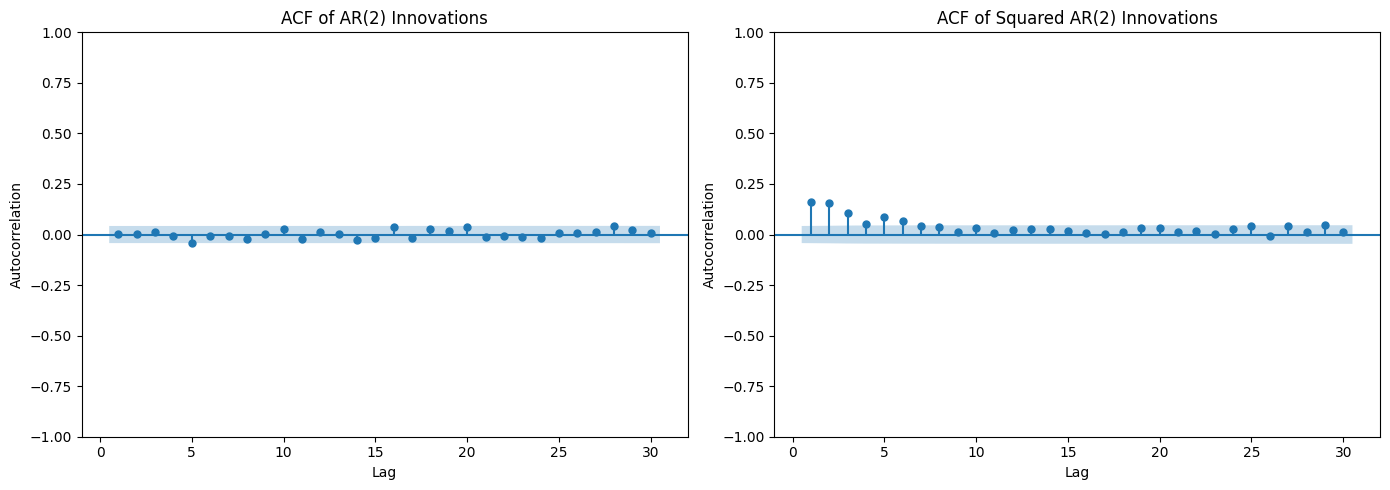

In [10]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5)
)

plot_acf(
    train_innovations,
    lags=30,
    zero=False,
    ax=axes[0]
)

axes[0].set_title(
    "ACF of AR(2) Innovations"
)
axes[0].set_xlabel("Lag")
axes[0].set_ylabel("Autocorrelation")

plot_acf(
    train_innovations.pow(2),
    lags=30,
    zero=False,
    ax=axes[1]
)

axes[1].set_title(
    "ACF of Squared AR(2) Innovations"
)
axes[1].set_xlabel("Lag")
axes[1].set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

### ACF of AR(2) Errors and Squared Errors

The ACF of the AR(2) innovations shows very little remaining autocorrelation, with most coefficients lying close to zero and within the confidence interval. This suggests that the AR(2) conditional-mean model has captured most of the linear dependence in the daily gilt-yield changes.

In contrast, the ACF of the **squared innovations** shows clear positive autocorrelation, particularly at the first several lags, with a number of coefficients lying outside the confidence interval. This indicates that although the residuals themselves are approximately uncorrelated, the magnitude of the residuals is dependent over time.

This pattern is consistent with **volatility clustering** and supports the ARCH-LM results. Therefore, the residual variance is not behaving as a constant over time, providing further justification for fitting ARCH-family conditional-volatility models such as ARCH, GARCH, EGARCH, GJR-GARCH and TARCH.

#### Select the ARCH order

ARCH orders from 1 to 10 are compared using AIC and BIC on the same pre-crisis training errors.

In [11]:
DIST = "t"
ARCH_MAX_P = 10
COMMON_HOLD_BACK = ARCH_MAX_P

arch_order_rows = []

for p in range(1, ARCH_MAX_P + 1):
    try:
        model = arch_model(
            train_innovations,
            mean="Zero",
            vol="ARCH",
            p=p,
            dist=DIST,
            hold_back=COMMON_HOLD_BACK,
            rescale=False
        )

        fit = model.fit(
            disp="off",
            show_warning=False
        )

        arch_order_rows.append({
            "p": p,
            "AIC": fit.aic,
            "BIC": fit.bic,
            "loglikelihood": fit.loglikelihood,
            "convergence_flag": fit.convergence_flag
        })

    except Exception as exc:
        arch_order_rows.append({
            "p": p,
            "AIC": np.nan,
            "BIC": np.nan,
            "loglikelihood": np.nan,
            "convergence_flag": np.nan
        })

arch_order_selection = (
    pd.DataFrame(arch_order_rows)
    .dropna(subset=["AIC"])
    .sort_values(["AIC", "BIC"])
    .reset_index(drop=True)
)

best_arch_p = int(
    arch_order_selection.loc[0, "p"]
)

print(
    f"Selected ARCH order by AIC: ARCH({best_arch_p})"
)

arch_order_selection

Selected ARCH order by AIC: ARCH(7)


,p,AIC,BIC,loglikelihood,convergence_flag
0,7,12380.663684,12431.647026,-6181.331842,0
1,6,12381.205453,12426.523979,-6182.602726,0
2,8,12381.972146,12438.620304,-6180.986073,0
3,9,12383.688818,12446.001792,-6180.844409,0
4,10,12385.544438,12453.522228,-6180.772219,0
5,5,12390.320102,12429.973813,-6188.160051,0
6,4,12393.166017,12427.154911,-6190.583008,0
7,3,12394.810632,12423.134711,-6192.405316,0
8,2,12409.470205,12432.129468,-6200.735103,0
9,1,12427.144181,12444.138628,-6210.572090,0


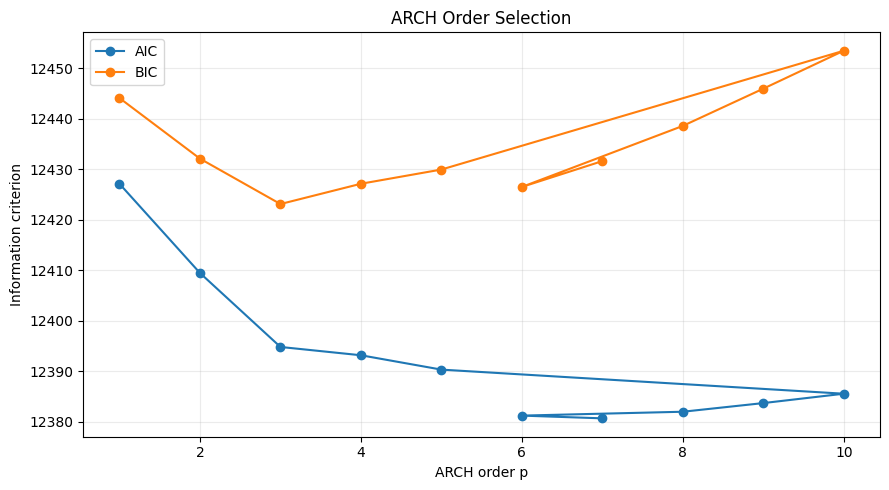

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(
    arch_order_selection["p"],
    arch_order_selection["AIC"],
    marker="o",
    label="AIC"
)

ax.plot(
    arch_order_selection["p"],
    arch_order_selection["BIC"],
    marker="o",
    label="BIC"
)

ax.set_title("ARCH Order Selection")
ax.set_xlabel("ARCH order p")
ax.set_ylabel("Information criterion")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

#### ARCH Order Selection

The ARCH order was selected by comparing ARCH models with orders $p=1,\ldots,10$ using the Akaike Information Criterion (AIC) and Bayesian Information Criterion (BIC). For both criteria, **lower values indicate a preferred model**.

The table and ARCH order-selection plot show that the AIC decreases substantially as the ARCH order increases from 1 to 3 and continues to improve more gradually until reaching its minimum at **ARCH(7)**. ARCH(7) has the lowest AIC value of **12380.66**, so it is selected by the AIC. ARCH(6) is very close, with an AIC of **12381.21**, indicating that the improvement from adding the seventh lag is relatively small.

The BIC follows a different pattern because it penalises additional parameters more strongly. The lowest BIC is **12423.13 for ARCH(3)**, after which the BIC begins to increase. Therefore, BIC favours the more parsimonious ARCH(3) specification, whereas AIC favours ARCH(7).

Since **AIC is used as the primary order-selection criterion in this analysis, ARCH(7) is retained** for the subsequent comparison with GARCH, EGARCH, GJR-GARCH and TARCH. All tested specifications have a `convergence_flag` of 0, indicating that the models converged successfully.

### Define the conditional-volatility models

All models use the same AR(2) innovations and Student-\(t\) conditional distribution.

In [13]:
MODEL_SPECS = {
    f"ARCH({best_arch_p})": {
        "vol": "ARCH",
        "p": best_arch_p
    },

    "GARCH(1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 0,
        "q": 1,
        "power": 2.0
    },

    "EGARCH(1,1,1)": {
        "vol": "EGARCH",
        "p": 1,
        "o": 1,
        "q": 1
    },

    "GJR-GARCH(1,1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "power": 2.0
    },

    "TARCH(1,1,1)": {
        "vol": "GARCH",
        "p": 1,
        "o": 1,
        "q": 1,
        "power": 1.0
    }
}


def build_volatility_model(
    innovations,
    spec,
    hold_back=COMMON_HOLD_BACK
):
    kwargs = {
        "y": pd.Series(innovations).dropna().astype(float),
        "mean": "Zero",
        "vol": spec["vol"],
        "p": spec["p"],
        "dist": DIST,
        "hold_back": hold_back,
        "rescale": False
    }

    if "o" in spec:
        kwargs["o"] = spec["o"]

    if "q" in spec:
        kwargs["q"] = spec["q"]

    if "power" in spec:
        kwargs["power"] = spec["power"]

    return arch_model(**kwargs)


def fit_volatility_model(
    innovations,
    spec,
    hold_back=COMMON_HOLD_BACK
):
    model = build_volatility_model(
        innovations,
        spec,
        hold_back=hold_back
    )

    return model.fit(
        disp="off",
        show_warning=False
    )

### Fit the five volatility models on the pre-crisis training innovations

In [14]:
train_vol_fits = {}

for name, spec in MODEL_SPECS.items():
    train_vol_fits[name] = fit_volatility_model(
        train_innovations,
        spec
    )

fit_comparison = pd.DataFrame([
    {
        "model": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "loglikelihood": fit.loglikelihood,
        "convergence_flag": fit.convergence_flag
    }
    for name, fit in train_vol_fits.items()
]).sort_values(
    ["AIC", "BIC"]
).reset_index(drop=True)

fit_comparison

,model,AIC,BIC,loglikelihood,convergence_flag
0,"EGARCH(1,1,1)",12369.497364,12397.821443,-6179.748682,0
1,"TARCH(1,1,1)",12370.100084,12398.424163,-6180.050042,0
2,"GARCH(1,1)",12370.393489,12393.052752,-6181.196744,0
3,"GJR-GARCH(1,1,1)",12371.154709,12399.478788,-6180.577354,0
4,ARCH(7),12380.663684,12431.647026,-6181.331842,0


In [15]:
for name, fit in train_vol_fits.items():
    print("=" * 90)
    print(name)
    print("=" * 90)
    print(fit.summary())
    print()

ARCH(7)
                           Zero Mean - ARCH Model Results                           
Dep. Variable:                         None   R-squared:                       0.000
Mean Model:                       Zero Mean   Adj. R-squared:                  0.000
Vol Model:                             ARCH   Log-Likelihood:               -6181.33
Distribution:      Standardized Student's t   AIC:                           12380.7
Method:                  Maximum Likelihood   BIC:                           12431.6
                                              No. Observations:                 2132
Date:                      Sat, Aug 29 2026   Df Residuals:                     2132
Time:                              20:53:45   Df Model:                            0
                               Volatility Model                              
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------

In [16]:
parameter_rows = []

for model_name, fit in train_vol_fits.items():
    for parameter, value in fit.params.items():
        parameter_rows.append({
            "model": model_name,
            "parameter": parameter,
            "estimate": value
        })

parameter_table = pd.DataFrame(
    parameter_rows
)

parameter_table

,model,parameter,estimate
0,ARCH(7),omega,11.357100
1,ARCH(7),alpha[1],0.079747
2,ARCH(7),alpha[2],0.098768
3,ARCH(7),alpha[3],0.078963
4,ARCH(7),alpha[4],0.029577
5,ARCH(7),alpha[5],0.060166
6,ARCH(7),alpha[6],0.089607
7,ARCH(7),alpha[7],0.036526
8,ARCH(7),nu,8.069793
9,"GARCH(1,1)",omega,1.330285


### Comparison of Conditional-Volatility Models and Parameter Estimates

**EGARCH(1,1,1)** has the lowest AIC (**12369.50**), while **GARCH(1,1)** has the lowest BIC (**12393.05**). EGARCH, TARCH, GARCH and GJR-GARCH have very similar AIC values, whereas ARCH(7) performs worse. All models converged successfully.

The parameter estimates show strong **volatility persistence**, with large and significant $\beta_1$ values for GARCH, EGARCH, GJR-GARCH and TARCH. However, the asymmetry parameters $\gamma_1$ in EGARCH, GJR-GARCH and TARCH are not statistically significant, so there is little evidence that positive and negative yield shocks affect volatility differently.

The Student-$t$ degrees-of-freedom parameter is around **7–8** across the models, supporting the use of a heavy-tailed distribution. The **EGARCH(1,1,1) is preferred by AIC**, while **GARCH(1,1) is preferred by BIC**, with the main feature of the data being persistent rather than strongly asymmetric volatility.

### Fitted pre-crisis conditional volatility

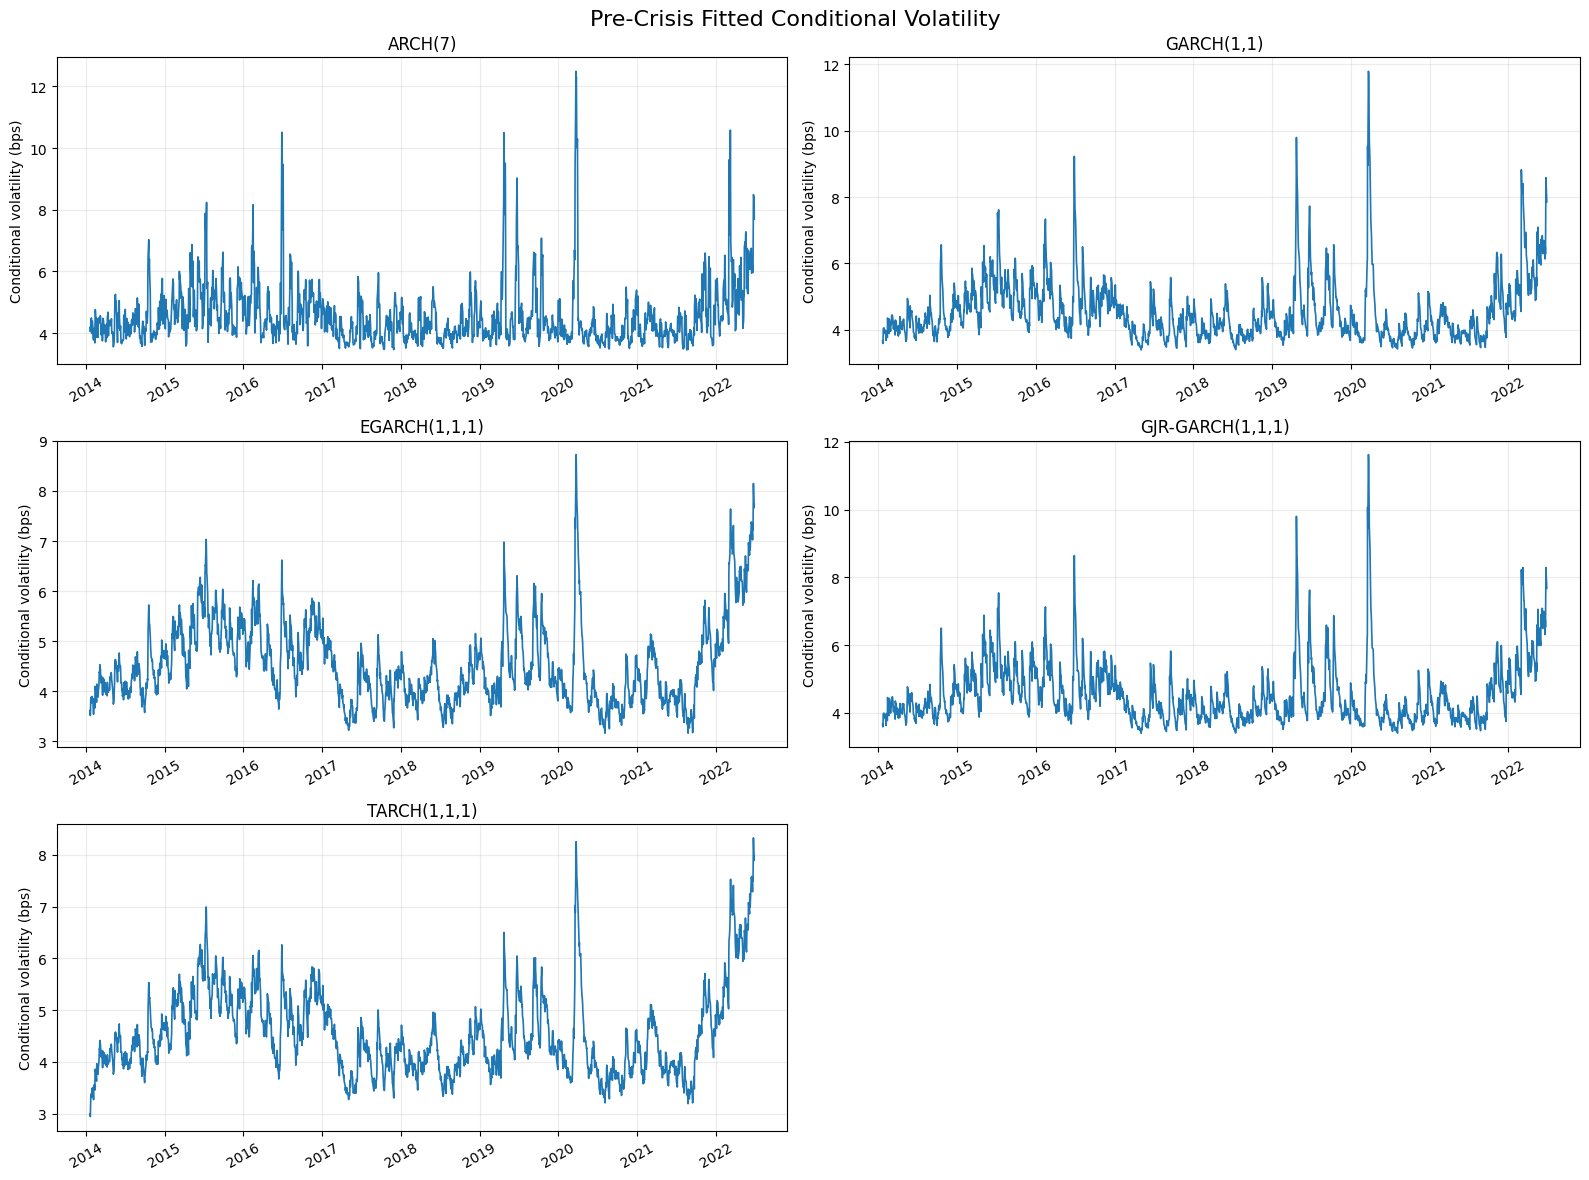

In [17]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (name, fit) in zip(
    axes[:5],
    train_vol_fits.items()
):
    sigma = pd.Series(
        fit.conditional_volatility
    ).dropna()

    dates = train_level.loc[
        sigma.index,
        "date"
    ]

    ax.plot(
        dates,
        sigma,
        linewidth=1.2
    )

    ax.set_title(name)
    ax.set_ylabel("Conditional volatility (bps)")
    ax.grid(alpha=0.25)
    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis("off")

plt.suptitle(
    "Pre-Crisis Fitted Conditional Volatility",
    fontsize=16
)

plt.tight_layout()
plt.show()

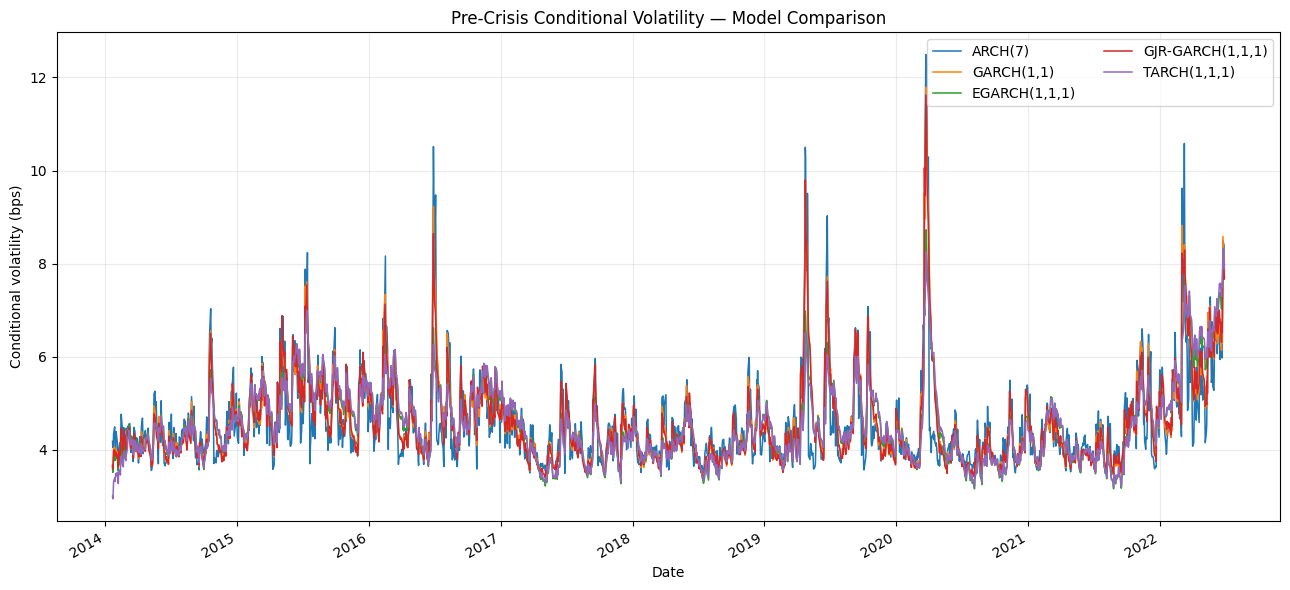

In [18]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

for name, fit in train_vol_fits.items():
    sigma = pd.Series(
        fit.conditional_volatility
    ).dropna()

    dates = train_level.loc[
        sigma.index,
        "date"
    ]

    ax.plot(
        dates,
        sigma,
        linewidth=1.1,
        label=name
    )

ax.set_title(
    "Pre-Crisis Conditional Volatility — Model Comparison"
)
ax.set_xlabel("Date")
ax.set_ylabel("Conditional volatility (bps)")
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### Pre-Crisis Fitted Conditional Volatility

All five models identify similar periods of elevated volatility, with clear spikes around 2015–2016, 2019–2020, and again approaching 2022. This indicates that volatility is time-varying and tends to cluster rather than remaining constant.

ARCH(7) produces the sharpest and most irregular spikes, while GARCH, EGARCH, GJR-GARCH and TARCH generate smoother and more persistent volatility paths. The combined comparison shows that the models broadly agree on the timing of high- and low-volatility periods.

Volatility rises noticeably during 2022 as the sample approaches the gilt crisis, suggesting that market uncertainty was already increasing before 23 September. EGARCH and TARCH produce slightly smoother paths, while ARCH(7) reacts more strongly to individual shocks.

### Volatility-model residual diagnostics

For a well-specified conditional-variance model, standardised residuals should not retain systematic serial dependence in either the residuals or their squares.

The diagnostics reported below are:

- Ljung-Box tests on standardised residuals;
- Ljung-Box tests on squared standardised residuals;
- ARCH-LM test on standardised residuals;
- Jarque-Bera distributional diagnostic.

In [19]:
def safe_lb_pvalue(series, lag):
    series = pd.Series(series).dropna()

    if len(series) <= lag + 5:
        return np.nan

    result = acorr_ljungbox(
        series,
        lags=[lag],
        return_df=True
    )

    return float(
        result["lb_pvalue"].iloc[-1]
    )


diagnostic_rows = []

for name, fit in train_vol_fits.items():

    std_resid = (
        pd.Series(fit.std_resid)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    std_resid_sq = std_resid.pow(2)

    lm_stat, lm_p, _, _ = het_arch(
        std_resid,
        nlags=10
    )

    jb = jarque_bera(
        std_resid
    )

    diagnostic_rows.append({
        "model": name,
        "LB resid p (10)": safe_lb_pvalue(
            std_resid, 10
        ),
        "LB resid p (20)": safe_lb_pvalue(
            std_resid, 20
        ),
        "LB squared resid p (10)": safe_lb_pvalue(
            std_resid_sq, 10
        ),
        "LB squared resid p (20)": safe_lb_pvalue(
            std_resid_sq, 20
        ),
        "ARCH-LM p (10)": lm_p,
        "Jarque-Bera statistic": jb.statistic,
        "Jarque-Bera p": jb.pvalue
    })

volatility_diagnostics = pd.DataFrame(
    diagnostic_rows
)

volatility_diagnostics

,model,LB resid p (10),LB resid p (20),LB squared resid p (10),LB squared resid p (20),ARCH-LM p (10),Jarque-Bera statistic,Jarque-Bera p
0,ARCH(7),0.873096,0.701353,0.997110,0.998934,0.997207,279.962291,1.610501e-61
1,"GARCH(1,1)",0.865827,0.679452,0.661280,0.950066,0.659640,284.284265,1.855479e-62
2,"EGARCH(1,1,1)",0.800827,0.597880,0.005029,0.043273,0.012379,306.871110,2.310922e-67
3,"GJR-GARCH(1,1,1)",0.840467,0.642884,0.677150,0.955814,0.676500,270.731358,1.627169e-59
4,"TARCH(1,1,1)",0.786507,0.589465,0.000313,0.005023,0.001471,334.094972,2.832687e-73


#### Volatility-Model Residual Diagnostics

The Ljung-Box p-values for the **standardised residuals** are above 0.05 for all five models, indicating little remaining linear autocorrelation after modelling the conditional mean and volatility.

For the **squared standardised residuals**, ARCH(7), GARCH(1,1), and GJR-GARCH(1,1,1) all have p-values above 0.05, and their ARCH-LM p-values are also above 0.05. This suggests that these models have successfully removed most of the remaining ARCH structure.

In contrast, **EGARCH(1,1,1)** and **TARCH(1,1,1)** have squared-residual and ARCH-LM p-values below 0.05, indicating that some conditional heteroskedasticity remains after fitting these models.

The Jarque-Bera p-values are extremely small for every model, so normality is rejected. This is not unexpected because the models use a **Student-\(t\) distribution**, which is specifically designed to allow heavier tails than the Gaussian distribution.

Although EGARCH had the lowest AIC, the residual diagnostics favour **GARCH(1,1), GJR-GARCH(1,1,1), and ARCH(7)** because they leave little evidence of remaining ARCH effects.

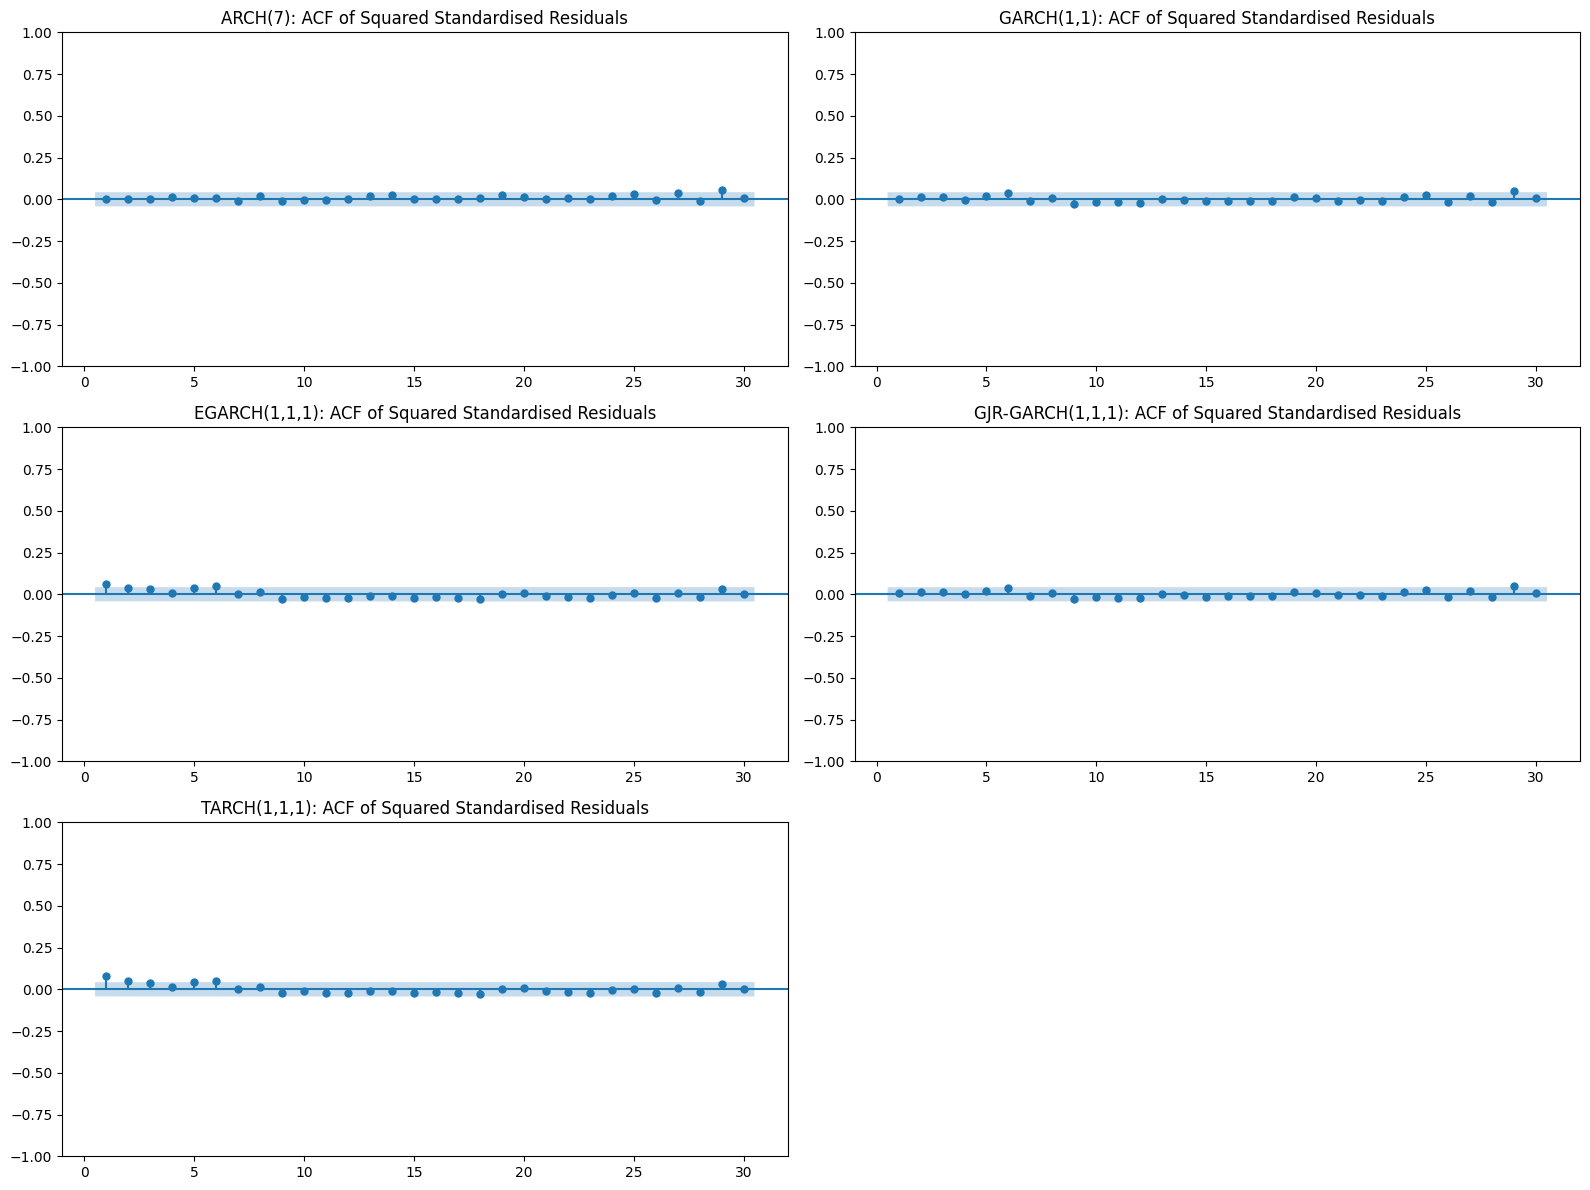

In [20]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, (name, fit) in zip(
    axes[:5],
    train_vol_fits.items()
):
    std_resid = (
        pd.Series(fit.std_resid)
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    plot_acf(
        std_resid.pow(2),
        lags=30,
        zero=False,
        ax=ax
    )

    ax.set_title(
        f"{name}: ACF of Squared Standardised Residuals"
    )

axes[5].axis("off")

plt.tight_layout()
plt.show()

#### ACF of Squared Standardised Residuals

The ACF plots show that **ARCH(7), GARCH(1,1), and GJR-GARCH(1,1,1)** leave very little autocorrelation in the squared standardised residuals, with almost all lags remaining within the confidence bands. This suggests that these models capture most of the conditional-variance dependence.

In contrast, **EGARCH(1,1,1)** and **TARCH(1,1,1)** show noticeable positive autocorrelation at the first few lags, with some coefficients exceeding the confidence bands. This is consistent with the earlier Ljung-Box and ARCH-LM results, which indicated remaining ARCH effects for these two models.

### Volatility forecast loss functions

Because the true conditional variance is latent, squared innovations are used as a realised-variance proxy.

The reported losses are:

$$
QLIKE_t=
\log(\hat h_t)
+
\frac{\varepsilon_t^2}{\hat h_t},
$$

along with MAE and RMSE for variance forecasts and for volatility-scale forecasts.

In [21]:
EPS = 1e-10

def volatility_metrics(
    realized_innovation,
    forecast_variance
):
    realized_innovation = np.asarray(
        realized_innovation,
        dtype=float
    )

    forecast_variance = np.asarray(
        forecast_variance,
        dtype=float
    )

    realized_sq = (
        realized_innovation ** 2
    )

    forecast_variance = np.maximum(
        forecast_variance,
        EPS
    )

    qlike = np.mean(
        np.log(forecast_variance)
        + realized_sq / forecast_variance
    )

    variance_error = (
        forecast_variance - realized_sq
    )

    realized_abs = np.abs(
        realized_innovation
    )

    forecast_sigma = np.sqrt(
        forecast_variance
    )

    sigma_error = (
        forecast_sigma - realized_abs
    )

    return {
        "QLIKE": qlike,

        "Variance MAE (bps²)": np.mean(
            np.abs(variance_error)
        ),

        "Variance RMSE (bps²)": np.sqrt(
            np.mean(
                variance_error ** 2
            )
        ),

        "Volatility MAE (bps)": np.mean(
            np.abs(sigma_error)
        ),

        "Volatility RMSE (bps)": np.sqrt(
            np.mean(
                sigma_error ** 2
            )
        )
    }


def simulated_variance_forecast(
    fit,
    horizon,
    simulations=5000,
    seed=42
):
    np.random.seed(seed)

    forecast = fit.forecast(
        horizon=horizon,
        method="simulation",
        simulations=simulations,
        reindex=False
    )

    variance = (
        forecast.variance
        .iloc[-1]
        .to_numpy(dtype=float)
    )

    return np.maximum(
        variance,
        EPS
    )

### Fixed-origin pre-crisis volatility validation

The volatility models are fitted once at the beginning of the 60-observation validation window.

Neither the AR(2) conditional mean nor the volatility models receive any validation observations while producing the 60-step fixed-origin forecast.

Simulation forecasts are used for all five volatility models so that ARCH, GARCH, EGARCH, GJR-GARCH and TARCH are evaluated using the same forecasting method.

In [23]:
N_SIMULATIONS = 5000

fixed_mean_forecast = (
    train_mean_fit
    .get_forecast(
        steps=HORIZON
    )
    .predicted_mean
)

fixed_mean_forecast = np.asarray(
    fixed_mean_forecast,
    dtype=float
)

fixed_actual_changes = np.asarray(
    test_changes,
    dtype=float
)

fixed_realized_innovations = (
    fixed_actual_changes
    - fixed_mean_forecast
)

fixed_variance_forecasts = {}

for i, (name, fit) in enumerate(
    train_vol_fits.items()
):
    fixed_variance_forecasts[name] = (
        simulated_variance_forecast(
            fit,
            horizon=HORIZON,
            simulations=N_SIMULATIONS,
            seed=SEED + i
        )
    )


fixed_validation_table = pd.DataFrame({
    "date": test_level["date"],
    "actual_change_bps": fixed_actual_changes,
    "AR2_mean_forecast_bps": fixed_mean_forecast,
    "realised_innovation_bps": fixed_realized_innovations,
    "realised_squared_innovation_bps2": (
        fixed_realized_innovations ** 2
    ),
    "realised_abs_innovation_bps": np.abs(
        fixed_realized_innovations
    )
})

for name, variance in fixed_variance_forecasts.items():
    fixed_validation_table[
        f"{name} variance forecast"
    ] = variance

    fixed_validation_table[
        f"{name} sigma forecast"
    ] = np.sqrt(variance)

fixed_validation_table.head(10)

,date,actual_change_bps,AR2_mean_forecast_bps,realised_innovation_bps,realised_squared_innovation_bps2,realised_abs_innovation_bps,ARCH(7) variance forecast,ARCH(7) sigma forecast,"GARCH(1,1) variance forecast","GARCH(1,1) sigma forecast","EGARCH(1,1,1) variance forecast","EGARCH(1,1,1) sigma forecast","GJR-GARCH(1,1,1) variance forecast","GJR-GARCH(1,1,1) sigma forecast","TARCH(1,1,1) variance forecast","TARCH(1,1,1) sigma forecast"
0,2022-06-29,-8.98,-0.710411,-8.269589,68.386106,8.269589,54.390489,7.374991,60.803449,7.797657,61.921375,7.869014,59.413290,7.708002,66.131153,8.132106
1,2022-06-30,-10.24,-0.384072,-9.855928,97.139315,9.855928,70.677586,8.406996,58.305466,7.635802,60.240887,7.761500,57.235712,7.565429,65.036417,8.064516
2,2022-07-01,-17.39,0.012751,-17.402751,302.855753,17.402751,67.307799,8.204133,55.990031,7.482649,58.683963,7.660546,55.151052,7.426375,63.919490,7.994967
3,2022-07-04,13.00,-0.015495,13.015495,169.403099,13.015495,45.332341,6.732930,53.853291,7.338480,57.287017,7.568819,53.106665,7.287432,62.791785,7.924127
4,2022-07-05,-12.22,-0.031885,-12.188115,148.550145,12.188115,39.496237,6.284603,51.911155,7.204940,55.867974,7.474488,51.242370,7.158378,61.691167,7.854372
5,2022-07-06,1.07,-0.030072,1.100072,1.210157,1.100072,39.400302,6.276966,49.733722,7.052214,54.431694,7.377784,49.358225,7.025541,60.633178,7.786731
6,2022-07-07,2.35,-0.029417,2.379417,5.661627,2.379417,36.283403,6.023571,48.009449,6.928885,53.109438,7.287622,47.525868,6.893901,59.597603,7.719948
7,2022-07-08,11.13,-0.029520,11.159520,124.534880,11.159520,35.000252,5.916101,46.083307,6.788469,52.014685,7.212121,45.943992,6.778200,58.616530,7.656143
8,2022-07-11,-4.08,-0.029545,-4.050455,16.406188,4.050455,33.345372,5.774545,44.635819,6.681004,50.793772,7.126975,44.301393,6.655929,57.534532,7.585152
9,2022-07-12,-8.32,-0.029539,-8.290461,68.731737,8.290461,30.496870,5.522397,43.208362,6.573307,49.650741,7.046328,42.934947,6.552476,56.615178,7.524306


In [24]:
fixed_metric_rows = []

for name, variance in (
    fixed_variance_forecasts.items()
):
    row = {
        "model": name
    }

    row.update(
        volatility_metrics(
            fixed_realized_innovations,
            variance
        )
    )

    fixed_metric_rows.append(row)

fixed_volatility_metrics = (
    pd.DataFrame(fixed_metric_rows)
    .sort_values("QLIKE")
    .reset_index(drop=True)
)

fixed_volatility_metrics

,model,QLIKE,Variance MAE (bps²),Variance RMSE (bps²),Volatility MAE (bps),Volatility RMSE (bps)
0,"TARCH(1,1,1)",5.490509,60.755764,83.751348,4.164397,4.845732
1,"EGARCH(1,1,1)",5.638466,60.793858,85.886041,4.170762,4.908676
2,"GJR-GARCH(1,1,1)",5.875990,60.933613,88.195225,4.190524,5.023796
3,"GARCH(1,1)",5.879186,60.890076,88.156198,4.188203,5.023715
4,ARCH(7),6.106318,60.727502,89.389553,4.188819,5.089812


Forecast performance is assessed using **QLIKE**, variance MAE/RMSE and volatility MAE/RMSE. Lower values indicate better forecast performance.

- **TARCH(1,1,1)** performs best overall, with the lowest QLIKE (**5.49**) and the lowest volatility MAE (**4.16 bps**) and RMSE (**4.85 bps**).
- **EGARCH(1,1,1)** is the second-best model according to QLIKE (**5.64**).
- GARCH and GJR-GARCH produce very similar results.
- **ARCH(7)** has the highest QLIKE (**6.11**) and volatility RMSE (**5.09 bps**), although its variance MAE is marginally the lowest.

Therefore, for this fixed-origin validation exercise, **TARCH(1,1,1) provides the strongest overall volatility forecast performance**. However, this result should be considered together with the residual diagnostics, where TARCH showed some remaining ARCH structure.

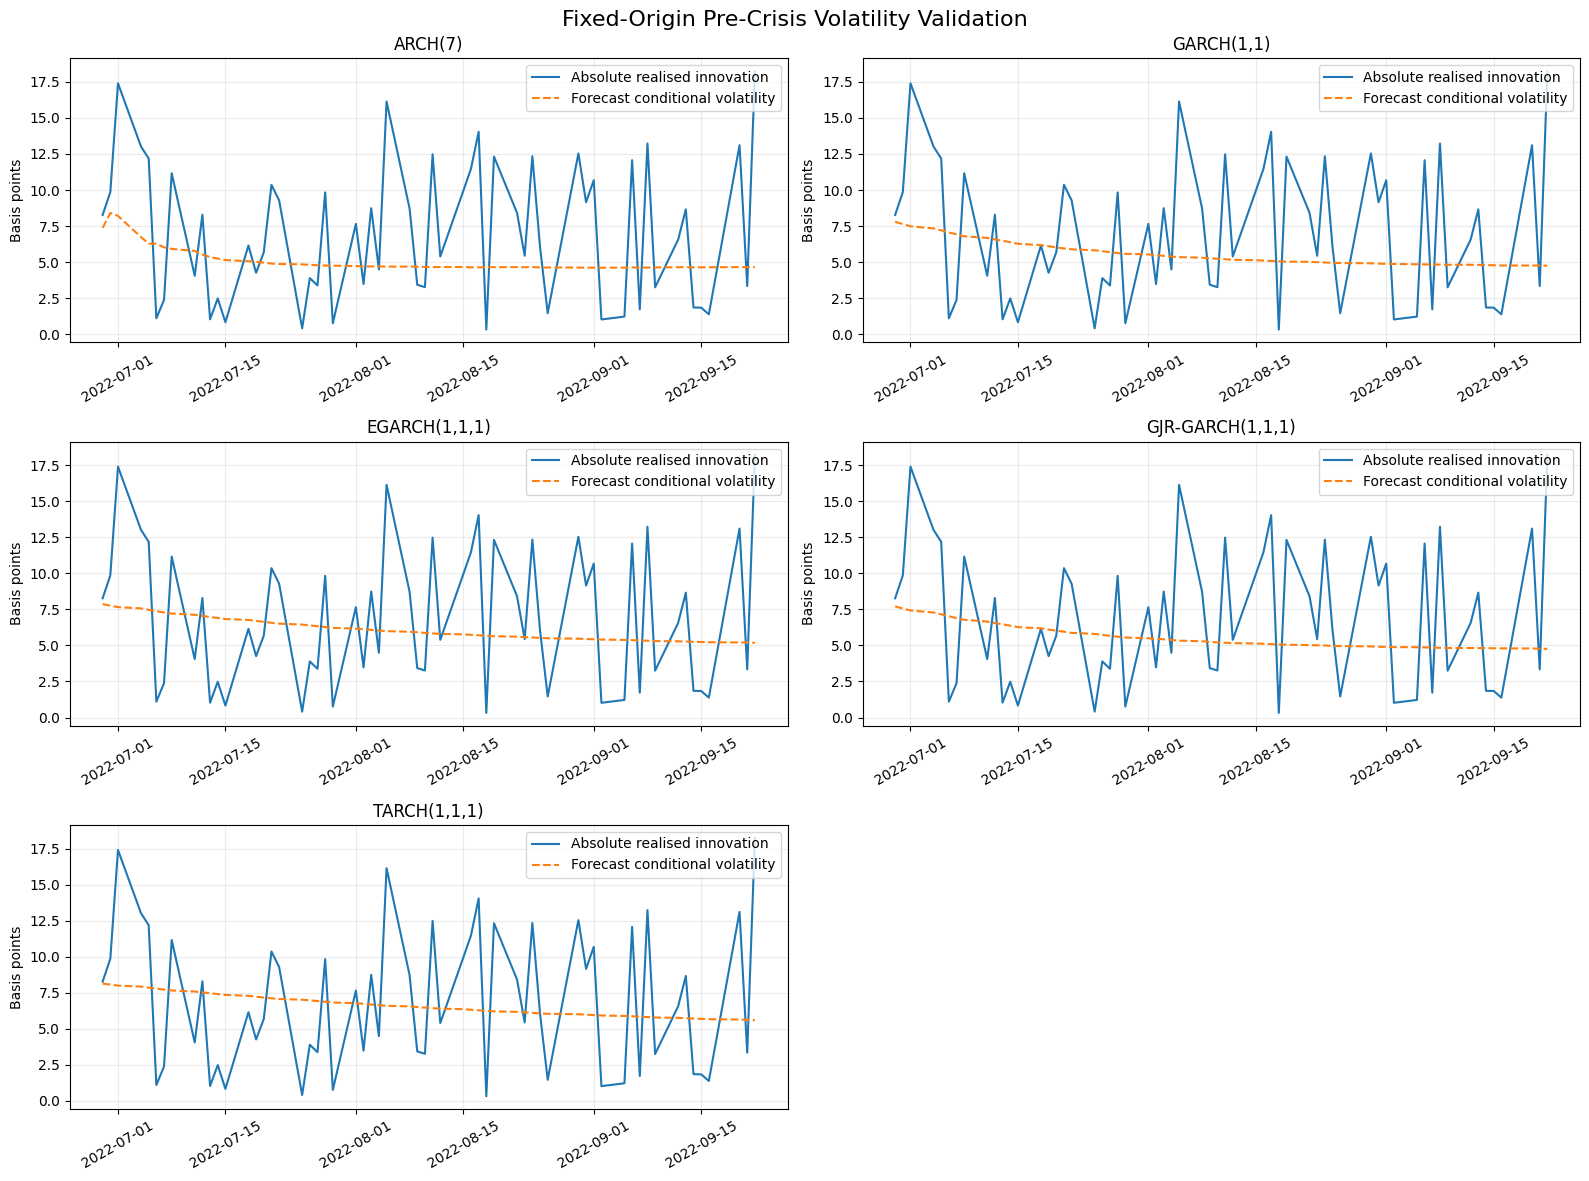

In [25]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, name in zip(
    axes[:5],
    MODEL_SPECS.keys()
):
    ax.plot(
        test_level["date"],
        np.abs(
            fixed_realized_innovations
        ),
        linewidth=1.5,
        label="Absolute realised innovation"
    )

    ax.plot(
        test_level["date"],
        np.sqrt(
            fixed_variance_forecasts[name]
        ),
        linestyle="--",
        linewidth=1.5,
        label="Forecast conditional volatility"
    )

    ax.set_title(name)
    ax.set_ylabel("Basis points")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis("off")

plt.suptitle(
    "Fixed-Origin Pre-Crisis Volatility Validation",
    fontsize=16
)

plt.tight_layout()
plt.show()

The fixed-origin forecasts are much smoother than the realised absolute innovations because the models are estimated once before the validation period and are **not updated with any of the 60 validation observations**.

All five models forecast conditional volatility to gradually decline toward a more stable long-run level, while the realised innovations remain highly variable with several large spikes. This shows the difficulty of forecasting individual volatility shocks over a long fixed horizon.

TARCH and EGARCH begin with slightly higher volatility forecasts and decline more gradually, while ARCH(7) adjusts more sharply. The plots are consistent with the validation metrics, where **TARCH(1,1,1)** gave the strongest fixed-origin forecasting performance.

#### Rolling one-step-ahead pre-crisis volatility validation

At each validation date:

1. only observations strictly before that date are used;
2. the AR(2) conditional mean is refitted;
3. the volatility model is refitted to the available AR(2) innovations;
4. a one-step conditional-variance forecast is generated;
5. the actual observation is then used only to evaluate that forecast and becomes available for the next forecast origin.

This is an expanding-window one-step-ahead backtest.

In [26]:
def one_step_variance_forecast(
    fit
):
    forecast = fit.forecast(
        horizon=1,
        method="analytic",
        reindex=False
    )

    value = float(
        forecast.variance.iloc[-1, 0]
    )

    return max(
        value,
        EPS
    )


rolling_rows = []

train_len = len(train_level)
total_len = len(pre_crisis)

for i in range(
    train_len,
    total_len
):
    history_changes = (
        pre_crisis["yield_change_bps"]
        .iloc[:i]
        .dropna()
        .astype(float)
    )

    mean_fit_i, innovations_i = (
        fit_mean_model(
            history_changes
        )
    )

    mean_forecast_i = float(
        mean_fit_i
        .get_forecast(steps=1)
        .predicted_mean
        .iloc[0]
    )

    actual_change_i = float(
        pre_crisis["yield_change_bps"]
        .iloc[i]
    )

    realized_innovation_i = (
        actual_change_i
        - mean_forecast_i
    )

    row = {
        "date": pre_crisis["date"].iloc[i],
        "actual_change_bps": actual_change_i,
        "AR2_mean_forecast_bps": mean_forecast_i,
        "realized_innovation_bps": realized_innovation_i,
        "realized_squared_innovation_bps2": (
            realized_innovation_i ** 2
        ),
        "realized_abs_innovation_bps": abs(
            realized_innovation_i
        )
    }

    for name, spec in MODEL_SPECS.items():
        vol_fit_i = fit_volatility_model(
            innovations_i,
            spec
        )

        variance_i = (
            one_step_variance_forecast(
                vol_fit_i
            )
        )

        row[
            f"{name} variance forecast"
        ] = variance_i

        row[
            f"{name} sigma forecast"
        ] = np.sqrt(
            variance_i
        )

    rolling_rows.append(row)

    completed = i - train_len + 1

    if (
        completed % 10 == 0
        or completed == HORIZON
    ):
        print(
            f"Completed "
            f"{completed}/{HORIZON} "
            f"rolling forecasts"
        )


rolling_validation_table = pd.DataFrame(
    rolling_rows
)

rolling_validation_table.head(10)

Completed 10/60 rolling forecasts
Completed 20/60 rolling forecasts
Completed 30/60 rolling forecasts
Completed 40/60 rolling forecasts
Completed 50/60 rolling forecasts
Completed 60/60 rolling forecasts


,date,actual_change_bps,AR2_mean_forecast_bps,realized_innovation_bps,realized_squared_innovation_bps2,realized_abs_innovation_bps,ARCH(7) variance forecast,ARCH(7) sigma forecast,"GARCH(1,1) variance forecast","GARCH(1,1) sigma forecast","EGARCH(1,1,1) variance forecast","EGARCH(1,1,1) sigma forecast","GJR-GARCH(1,1,1) variance forecast","GJR-GARCH(1,1,1) sigma forecast","TARCH(1,1,1) variance forecast","TARCH(1,1,1) sigma forecast"
0,2022-06-29,-8.98,-0.710411,-8.269589,68.386106,8.269589,54.390489,7.374991,60.803449,7.797657,61.921375,7.869014,59.413290,7.708002,66.131153,8.132106
1,2022-06-30,-10.24,-0.096721,-10.143279,102.886100,10.143279,72.024658,8.486734,59.075176,7.686038,61.465134,7.839970,57.001513,7.549935,65.889917,8.117260
2,2022-07-01,-17.39,0.740310,-18.130310,328.708126,18.130310,71.117674,8.433130,60.397044,7.771553,62.810823,7.925328,57.329730,7.571640,67.260383,8.201243
3,2022-07-04,13.00,0.933196,12.066804,145.607764,12.066804,71.256544,8.441359,80.727503,8.984849,72.355611,8.506210,74.252317,8.616978,76.189228,8.728644
4,2022-07-05,-12.22,0.303674,-12.523674,156.842401,12.523674,76.849861,8.766405,83.013709,9.111186,78.006281,8.832116,79.212412,8.900135,82.395048,9.077172
5,2022-07-06,1.07,-0.121497,1.191497,1.419664,1.191497,82.391746,9.076990,86.003269,9.273795,81.064155,9.003563,81.128208,9.007120,85.839847,9.264980
6,2022-07-07,2.35,0.417407,1.932593,3.734915,1.932593,64.171195,8.010693,74.803584,8.648906,72.232672,8.498981,70.631415,8.404250,77.365767,8.795781
7,2022-07-08,11.13,-0.184103,11.314103,128.008934,11.314103,60.645125,7.787498,65.472480,8.091507,65.312813,8.081634,61.941355,7.870283,70.821085,8.415526
8,2022-07-11,-4.08,-0.566841,-3.513159,12.342290,3.513159,71.842935,8.476021,68.550898,8.279547,70.746239,8.411078,67.010216,8.185977,76.213337,8.730025
9,2022-07-12,-8.32,-0.351458,-7.968542,63.497669,7.968542,62.230105,7.888606,60.916981,7.804933,65.086501,8.067621,59.566713,7.717947,70.803437,8.414478


The rolling backtest updates the AR(2) mean model and each volatility model after every realised validation observation, so each forecast is genuinely one-step ahead and uses only information available at that date.

Compared with the fixed-origin forecasts, the rolling forecasts adjust more quickly to recent changes in volatility. For example, after the large innovations at the start of July, the forecast conditional volatility rises across all models before gradually declining as smaller shocks are observed.

The models produce broadly similar one-step volatility forecasts, although ARCH(7) reacts somewhat more sharply to recent shocks while GARCH, EGARCH, GJR-GARCH and TARCH generate smoother and more persistent responses.

This rolling validation provides a more realistic measure of short-horizon volatility forecasting performance because the models are allowed to update as new pre-crisis information becomes available.

In [27]:
rolling_metric_rows = []

rolling_realized = (
    rolling_validation_table[
        "realized_innovation_bps"
    ]
    .to_numpy(dtype=float)
)

for name in MODEL_SPECS.keys():
    variance = (
        rolling_validation_table[
            f"{name} variance forecast"
        ]
        .to_numpy(dtype=float)
    )

    row = {
        "model": name
    }

    row.update(
        volatility_metrics(
            rolling_realized,
            variance
        )
    )

    rolling_metric_rows.append(row)

rolling_volatility_metrics = (
    pd.DataFrame(
        rolling_metric_rows
    )
    .sort_values("QLIKE")
    .reset_index(drop=True)
)

rolling_volatility_metrics

,model,QLIKE,Variance MAE (bps²),Variance RMSE (bps²),Volatility MAE (bps),Volatility RMSE (bps)
0,"TARCH(1,1,1)",5.339674,64.477201,83.460326,4.354129,5.069908
1,"EGARCH(1,1,1)",5.348945,63.897266,83.651290,4.317519,5.025408
2,"GJR-GARCH(1,1,1)",5.405380,63.221154,84.917375,4.276392,4.986389
3,"GARCH(1,1)",5.416228,62.844677,85.130486,4.255476,4.967464
4,ARCH(7),5.502740,61.783609,85.742831,4.187934,4.930429


The rolling one-step-ahead results are mixed across the evaluation metrics.

- **TARCH(1,1,1)** has the lowest **QLIKE (5.34)**, making it the best model under the primary volatility loss measure.
- **EGARCH(1,1,1)** is a very close second with QLIKE **5.35**.
- **ARCH(7)** has the lowest volatility MAE (**4.19 bps**) and RMSE (**4.93 bps**), despite having the highest QLIKE.
- GARCH and GJR-GARCH perform similarly across the metrics.

**TARCH(1,1,1) performs best according to QLIKE**, while ARCH(7) performs best according to absolute volatility-error measures. The differences between the models are relatively small, so no single specification dominates across every metric.

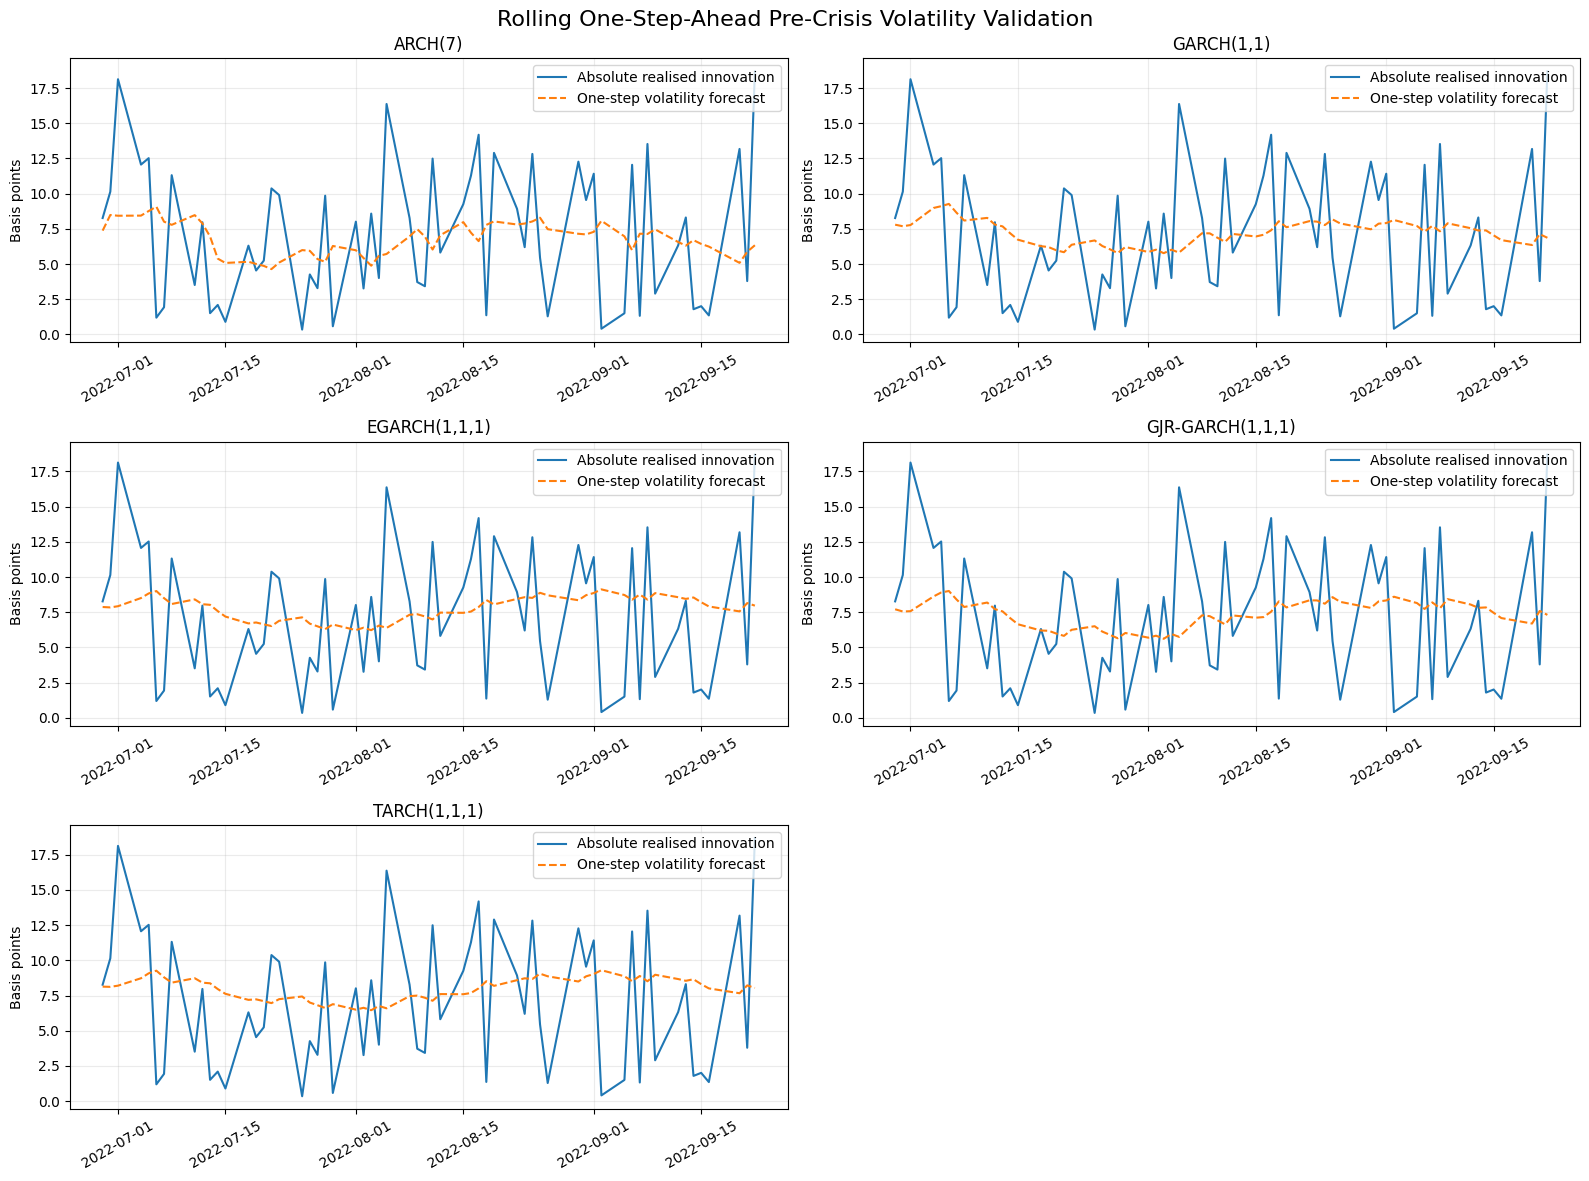

In [28]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, name in zip(
    axes[:5],
    MODEL_SPECS.keys()
):
    ax.plot(
        rolling_validation_table["date"],
        rolling_validation_table[
            "realized_abs_innovation_bps"
        ],
        linewidth=1.5,
        label="Absolute realised innovation"
    )

    ax.plot(
        rolling_validation_table["date"],
        rolling_validation_table[
            f"{name} sigma forecast"
        ],
        linestyle="--",
        linewidth=1.5,
        label="One-step volatility forecast"
    )

    ax.set_title(name)
    ax.set_ylabel("Basis points")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis("off")

plt.suptitle(
    "Rolling One-Step-Ahead Pre-Crisis Volatility Validation",
    fontsize=16
)

plt.tight_layout()
plt.show()

The rolling forecasts respond more dynamically than the fixed-origin forecasts because each model is updated after every new validation observation becomes available.

The orange one-step-ahead volatility forecasts generally rise after periods of larger realised innovations and decline after quieter periods. **ARCH(7)** reacts more sharply to recent shocks, while **GARCH, EGARCH, GJR-GARCH and TARCH** produce smoother and more persistent volatility paths.

The realised absolute innovations remain much more erratic than the forecast volatility, which is expected because the models forecast the **conditional scale of future shocks**, not the exact magnitude of each individual shock.

### Compare fixed-origin and rolling volatility forecast performance

In [29]:
fixed_for_merge = (
    fixed_volatility_metrics
    .rename(columns={
        "QLIKE": "fixed_QLIKE",
        "Variance MAE (bps²)": "fixed_variance_MAE_bps2",
        "Variance RMSE (bps²)": "fixed_variance_RMSE_bps2",
        "Volatility MAE (bps)": "fixed_volatility_MAE_bps",
        "Volatility RMSE (bps)": "fixed_volatility_RMSE_bps"
    })
)

rolling_for_merge = (
    rolling_volatility_metrics
    .rename(columns={
        "QLIKE": "rolling_QLIKE",
        "Variance MAE (bps²)": "rolling_variance_MAE_bps2",
        "Variance RMSE (bps²)": "rolling_variance_RMSE_bps2",
        "Volatility MAE (bps)": "rolling_volatility_MAE_bps",
        "Volatility RMSE (bps)": "rolling_volatility_RMSE_bps"
    })
)

validation_comparison = (
    fixed_for_merge
    .merge(
        rolling_for_merge,
        on="model",
        how="inner"
    )
    .sort_values(
        [
            "rolling_QLIKE",
            "fixed_QLIKE"
        ]
    )
    .reset_index(drop=True)
)

best_vol_model_name = (
    validation_comparison
    .iloc[0]["model"]
)

print(
    "Best volatility model by rolling QLIKE:",
    best_vol_model_name
)

validation_comparison

Best volatility model by rolling QLIKE: TARCH(1,1,1)


,model,fixed_QLIKE,fixed_variance_MAE_bps2,fixed_variance_RMSE_bps2,fixed_volatility_MAE_bps,fixed_volatility_RMSE_bps,rolling_QLIKE,rolling_variance_MAE_bps2,rolling_variance_RMSE_bps2,rolling_volatility_MAE_bps,rolling_volatility_RMSE_bps
0,"TARCH(1,1,1)",5.490509,60.755764,83.751348,4.164397,4.845732,5.339674,64.477201,83.460326,4.354129,5.069908
1,"EGARCH(1,1,1)",5.638466,60.793858,85.886041,4.170762,4.908676,5.348945,63.897266,83.651290,4.317519,5.025408
2,"GJR-GARCH(1,1,1)",5.875990,60.933613,88.195225,4.190524,5.023796,5.405380,63.221154,84.917375,4.276392,4.986389
3,"GARCH(1,1)",5.879186,60.890076,88.156198,4.188203,5.023715,5.416228,62.844677,85.130486,4.255476,4.967464
4,ARCH(7),6.106318,60.727502,89.389553,4.188819,5.089812,5.502740,61.783609,85.742831,4.187934,4.930429


Across both validation approaches, **TARCH(1,1,1)** achieves the lowest QLIKE, with **5.49** for the fixed-origin forecast and **5.34** for the rolling one-step-ahead forecast. Therefore, using QLIKE as the primary volatility-loss measure, **TARCH(1,1,1) is selected as the best forecasting model**.

The rolling procedure improves QLIKE for all five models because each model is updated as new pre-crisis observations become available. However, the other error measures do not produce exactly the same ranking. For example, **ARCH(7)** has the lowest rolling volatility MAE and RMSE, while TARCH performs best under QLIKE.

Overall, no model dominates every metric, but **TARCH(1,1,1) provides the strongest performance according to the primary QLIKE criterion**. This forecast result should still be considered alongside the residual diagnostics, where TARCH showed some remaining ARCH effects.

#### Refit the conditional mean using all pre-crisis information

The final pre-crisis information set ends on **22 September 2022**.

The AR(2) mean model is refitted once using all pre-crisis daily changes. Its in-sample innovations are then used to refit each volatility specification using the same model orders selected above.

In [30]:
all_precrisis_changes = (
    pre_crisis["yield_change_bps"]
    .dropna()
    .astype(float)
)

precrisis_mean_fit, precrisis_innovations = (
    fit_mean_model(
        all_precrisis_changes
    )
)

final_vol_fits = {}

for name, spec in MODEL_SPECS.items():
    final_vol_fits[name] = (
        fit_volatility_model(
            precrisis_innovations,
            spec
        )
    )

final_fit_comparison = pd.DataFrame([
    {
        "model": name,
        "AIC": fit.aic,
        "BIC": fit.bic,
        "loglikelihood": fit.loglikelihood,
        "convergence_flag": fit.convergence_flag
    }
    for name, fit in final_vol_fits.items()
]).sort_values(
    ["AIC", "BIC"]
).reset_index(drop=True)

final_fit_comparison

,model,AIC,BIC,loglikelihood,convergence_flag
0,"TARCH(1,1,1)",12804.472676,12832.935525,-6397.236338,0
1,"EGARCH(1,1,1)",12804.477884,12832.940732,-6397.238942,0
2,"GJR-GARCH(1,1,1)",12809.208915,12837.671764,-6399.604458,0
3,"GARCH(1,1)",12809.437405,12832.207683,-6400.718702,0
4,ARCH(7),12823.800426,12875.033553,-6402.900213,0


After validation, the AR(2) conditional-mean model and all volatility models were refitted using **all available pre-crisis data through 22 September 2022**.

**TARCH(1,1,1)** has the lowest AIC (**12804.47**), although EGARCH is effectively tied with an AIC of **12804.48**. **GARCH(1,1)** has the lowest BIC (**12832.21**), reflecting BIC's stronger penalty for model complexity. ARCH(7) performs worst according to both criteria.

All models converged successfully. Since **TARCH(1,1,1)** was also the best model under the primary rolling QLIKE criterion, it remains the preferred volatility specification for the subsequent no-crisis counterfactual forecast.

### No-crisis conditional-volatility counterfactual

The final information set is frozen on **22 September 2022**.

From 23 September onward:

- the AR(2) mean model is not updated;
- the ARCH-family volatility models are not updated;
- no realised crisis observation is fed back into either model;
- all forecast paths are fixed-origin forecasts generated from the pre-crisis information set.

Simulation is used for all five multi-step volatility forecasts so that EGARCH and TARCH can be included on the same basis.

In [31]:
CF_HORIZON = len(
    counterfactual_window
)

if CF_HORIZON == 0:
    raise ValueError(
        "Counterfactual window is empty."
    )

no_crisis_mean_forecast = (
    precrisis_mean_fit
    .get_forecast(
        steps=CF_HORIZON
    )
    .predicted_mean
)

no_crisis_mean_forecast = np.asarray(
    no_crisis_mean_forecast,
    dtype=float
)

no_crisis_variance_forecasts = {}

for i, (name, fit) in enumerate(
    final_vol_fits.items()
):
    no_crisis_variance_forecasts[name] = (
        simulated_variance_forecast(
            fit,
            horizon=CF_HORIZON,
            simulations=N_SIMULATIONS,
            seed=SEED + 100 + i
        )
    )

no_crisis_volatility_table = (
    counterfactual_window[
        [
            "date",
            "yield_10y",
            "yield_change_bps"
        ]
    ]
    .copy()
    .reset_index(drop=True)
)

no_crisis_volatility_table = (
    no_crisis_volatility_table.rename(
        columns={
            "yield_10y": "actual_yield_percent",
            "yield_change_bps": "actual_change_bps"
        }
    )
)

no_crisis_volatility_table[
    "fixed_AR2_mean_forecast_change_bps"
] = no_crisis_mean_forecast

no_crisis_volatility_table[
    "realized_innovation_bps"
] = (
    no_crisis_volatility_table[
        "actual_change_bps"
    ]
    - no_crisis_volatility_table[
        "fixed_AR2_mean_forecast_change_bps"
    ]
)

no_crisis_volatility_table[
    "realized_abs_innovation_bps"
] = (
    no_crisis_volatility_table[
        "realized_innovation_bps"
    ]
    .abs()
)

no_crisis_volatility_table[
    "realized_squared_innovation_bps2"
] = (
    no_crisis_volatility_table[
        "realized_innovation_bps"
    ] ** 2
)

for name, variance in (
    no_crisis_variance_forecasts.items()
):
    no_crisis_volatility_table[
        f"{name} variance forecast"
    ] = variance

    no_crisis_volatility_table[
        f"{name} sigma forecast"
    ] = np.sqrt(variance)

no_crisis_volatility_table.head(15)

,date,actual_yield_percent,actual_change_bps,fixed_AR2_mean_forecast_change_bps,realized_innovation_bps,realized_abs_innovation_bps,realized_squared_innovation_bps2,ARCH(7) variance forecast,ARCH(7) sigma forecast,"GARCH(1,1) variance forecast","GARCH(1,1) sigma forecast","EGARCH(1,1,1) variance forecast","EGARCH(1,1,1) sigma forecast","GJR-GARCH(1,1,1) variance forecast","GJR-GARCH(1,1,1) sigma forecast","TARCH(1,1,1) variance forecast","TARCH(1,1,1) sigma forecast"
0,2022-09-23,3.8426,29.10,-0.645880,29.745880,29.745880,884.817396,57.749577,7.599314,66.986776,8.184545,78.264506,8.846723,77.247166,8.789037,79.416238,8.911579
1,2022-09-26,4.1817,33.91,-0.412517,34.322517,34.322517,1178.035166,64.423800,8.026444,65.810718,8.112381,77.379420,8.796557,75.724577,8.701987,78.662734,8.869201
2,2022-09-27,4.4341,25.24,0.050109,25.189891,25.189891,634.530634,62.988260,7.936514,64.571624,8.035647,76.636473,8.754226,74.382487,8.624528,77.829525,8.822104
3,2022-09-28,4.0517,-38.24,0.029451,-38.269451,38.269451,1464.550843,61.568128,7.846536,63.466764,7.966603,75.898069,8.711950,73.150106,8.552784,77.118158,8.781694
4,2022-09-29,4.1210,6.93,0.018579,6.911421,6.911421,47.767739,64.423897,8.026450,62.069290,7.878407,75.145699,8.668662,71.928414,8.481062,76.281852,8.733948
5,2022-09-30,4.1021,-1.89,0.019443,-1.909443,1.909443,3.645972,72.807332,8.532721,60.944040,7.806666,74.361306,8.623300,70.569596,8.400571,75.626409,8.696345
6,2022-10-03,3.9766,-12.55,0.019686,-12.569686,12.569686,157.997011,60.544107,7.781009,59.775408,7.731456,73.678062,8.583593,69.474790,8.335154,74.954429,8.657623
7,2022-10-04,3.9036,-7.30,0.019657,-7.319657,7.319657,53.577376,46.100087,6.789704,58.684303,7.660568,72.900991,8.538208,68.291486,8.263866,74.208190,8.614418
8,2022-10-05,4.0527,14.91,0.019652,14.890348,14.890348,221.722472,44.203105,6.648542,57.720153,7.597378,72.341350,8.505372,67.190398,8.196975,73.593332,8.578656
9,2022-10-06,4.2134,16.07,0.019653,16.050347,16.050347,257.613651,41.785331,6.464157,56.783674,7.535494,71.667989,8.465695,66.233236,8.138380,72.943458,8.540694


#### Plot the no-crisis volatility forecasts

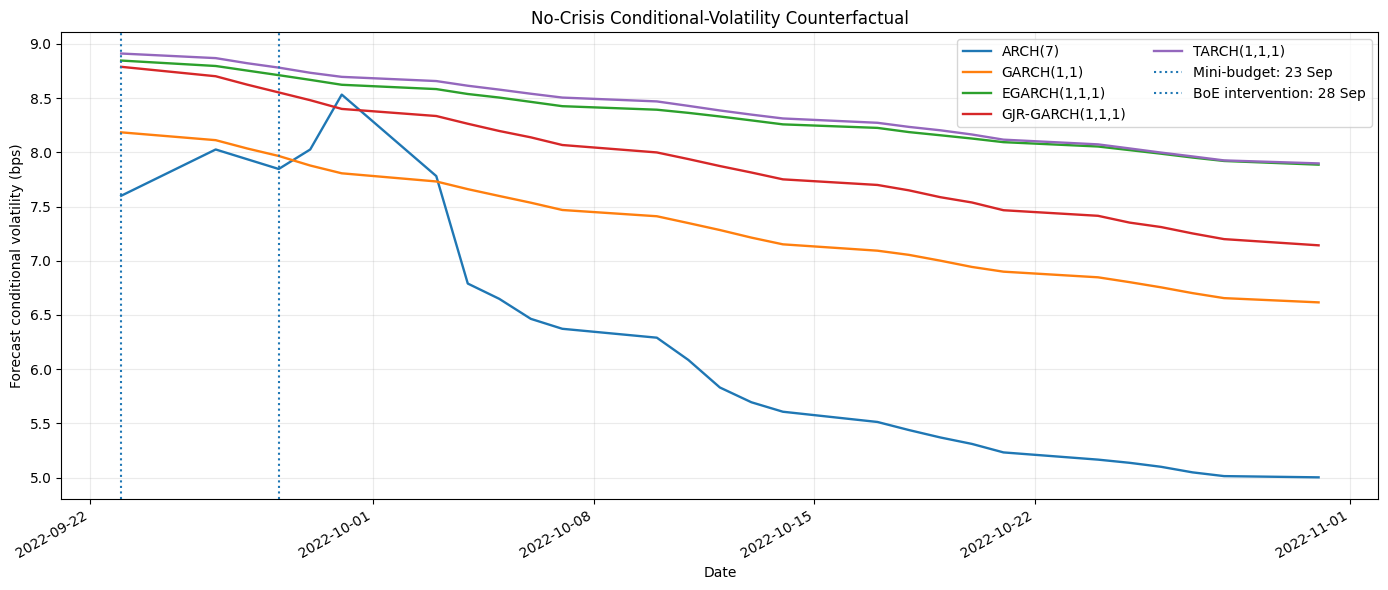

In [32]:
fig, ax = plt.subplots(
    figsize=(14, 6)
)

for name in MODEL_SPECS.keys():
    ax.plot(
        no_crisis_volatility_table["date"],
        no_crisis_volatility_table[
            f"{name} sigma forecast"
        ],
        linewidth=1.7,
        label=name
    )

ax.axvline(
    pd.Timestamp("2022-09-23"),
    linestyle=":",
    linewidth=1.5,
    label="Mini-budget: 23 Sep"
)

ax.axvline(
    pd.Timestamp("2022-09-28"),
    linestyle=":",
    linewidth=1.5,
    label="BoE intervention: 28 Sep"
)

ax.set_title(
    "No-Crisis Conditional-Volatility Counterfactual"
)
ax.set_xlabel("Date")
ax.set_ylabel(
    "Forecast conditional volatility (bps)"
)
ax.grid(alpha=0.25)
ax.legend(ncol=2)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The models were refitted using all available information through **22 September 2022** and then used to generate fixed-origin volatility forecasts from **23 September onward**, without feeding any crisis observations back into the models.

All five models forecast conditional volatility of roughly **7.6–8.9 bps** at the start of the crisis. In contrast, the realised absolute innovations were much larger: approximately **29.7 bps on 23 September**, **34.3 bps on 26 September**, and **25.2 bps on 27 September**. On 28 September, the realised innovation reached about **38.3 bps**, while the models still forecast volatility of only around **7.8–8.8 bps**. 

The forecast paths gradually decline over time because no crisis-period shocks are allowed to update the models. **EGARCH and TARCH produce the highest and most persistent no-crisis volatility paths**, while **ARCH(7) declines most rapidly**.

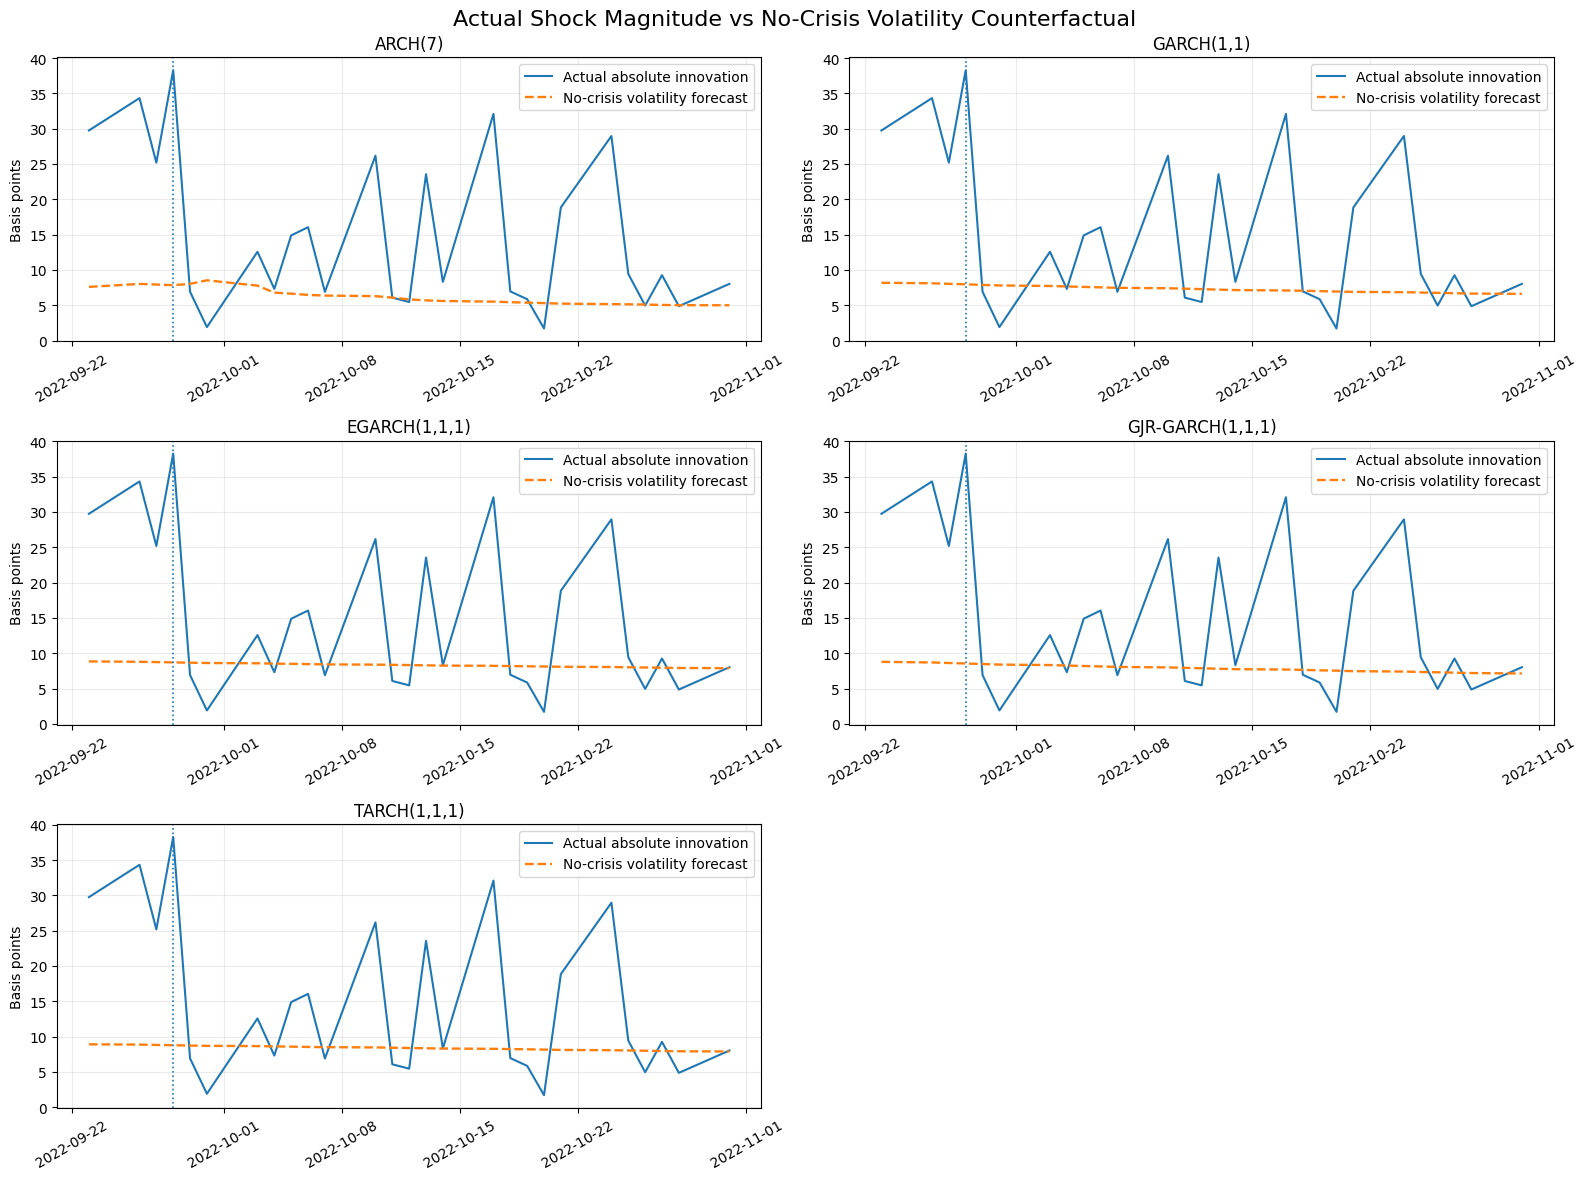

In [33]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(16, 12)
)

axes = axes.flatten()

for ax, name in zip(
    axes[:5],
    MODEL_SPECS.keys()
):
    ax.plot(
        no_crisis_volatility_table["date"],
        no_crisis_volatility_table[
            "realized_abs_innovation_bps"
        ],
        linewidth=1.5,
        label="Actual absolute innovation"
    )

    ax.plot(
        no_crisis_volatility_table["date"],
        no_crisis_volatility_table[
            f"{name} sigma forecast"
        ],
        linestyle="--",
        linewidth=1.7,
        label="No-crisis volatility forecast"
    )

    ax.axvline(
        pd.Timestamp("2022-09-28"),
        linestyle=":",
        linewidth=1.2
    )

    ax.set_title(name)
    ax.set_ylabel("Basis points")
    ax.grid(alpha=0.25)
    ax.legend()
    ax.tick_params(
        axis="x",
        rotation=30
    )

axes[5].axis("off")

plt.suptitle(
    "Actual Shock Magnitude vs No-Crisis Volatility Counterfactual",
    fontsize=16
)

plt.tight_layout()
plt.show()

The realised absolute errors are substantially larger than the no-crisis volatility forecasts at the start of the crisis. Between 23 and 28 September, realised shocks are around **25–38 bps**, while the models forecast conditional volatility of only about **8–9 bps**.

After 28 September, realised shocks remain highly variable and repeatedly exceed the model-implied no-crisis volatility paths. In contrast, the forecast paths remain smooth and generally decline because no crisis observations are fed back into the models.

**EGARCH and TARCH produce the most persistent volatility forecasts**, while **ARCH(7) declines more rapidly**.

### Standardise realised crisis innovations by the no-crisis volatility forecasts

In [39]:
no_crisis_standardized_table = (
    no_crisis_volatility_table[
        [
            "date",
            "actual_yield_percent",
            "actual_change_bps",
            "fixed_AR2_mean_forecast_change_bps",
            "realized_innovation_bps",
            "realized_abs_innovation_bps"
        ]
    ]
    .copy()
)

for name in MODEL_SPECS.keys():
    sigma = (
        no_crisis_volatility_table[
            f"{name} sigma forecast"
        ]
    )

    no_crisis_standardized_table[
        f"{name} standardized innovation"
    ] = (
        no_crisis_volatility_table[
            "realized_innovation_bps"
        ]
        / sigma
    )

no_crisis_standardized_table.head(15)

,date,actual_yield_percent,actual_change_bps,fixed_AR2_mean_forecast_change_bps,realized_innovation_bps,realized_abs_innovation_bps,ARCH(7) standardized innovation,"GARCH(1,1) standardized innovation","EGARCH(1,1,1) standardized innovation","GJR-GARCH(1,1,1) standardized innovation","TARCH(1,1,1) standardized innovation"
0,2022-09-23,3.8426,29.10,-0.645880,29.745880,29.745880,3.914285,3.634396,3.362361,3.384430,3.337891
1,2022-09-26,4.1817,33.91,-0.412517,34.322517,34.322517,4.276180,4.230881,3.901812,3.944216,3.869854
2,2022-09-27,4.4341,25.24,0.050109,25.189891,25.189891,3.173924,3.134768,2.877455,2.920727,2.855316
3,2022-09-28,4.0517,-38.24,0.029451,-38.269451,38.269451,-4.877241,-4.803735,-4.392754,-4.474502,-4.357866
4,2022-09-29,4.1210,6.93,0.018579,6.911421,6.911421,0.861081,0.877261,0.797288,0.814924,0.791328
5,2022-09-30,4.1021,-1.89,0.019443,-1.909443,1.909443,-0.223779,-0.244591,-0.221428,-0.227299,-0.219568
6,2022-10-03,3.9766,-12.55,0.019686,-12.569686,12.569686,-1.615431,-1.625785,-1.464385,-1.508033,-1.451863
7,2022-10-04,3.9036,-7.30,0.019657,-7.319657,7.319657,-1.078052,-0.955498,-0.857283,-0.885742,-0.849698
8,2022-10-05,4.0527,14.91,0.019652,14.890348,14.890348,2.239641,1.959933,1.750699,1.816566,1.735744
9,2022-10-06,4.2134,16.07,0.019653,16.050347,16.050347,2.482976,2.129966,1.895928,1.972180,1.879279


The standardised errors measure the size of each realised shock relative to the volatility predicted by each no-crisis model.

Values with an absolute magnitude above about **2** indicate unusually large shocks relative to the model-implied volatility. The crisis period contains several extreme observations. On **23 September**, the standardised innovations are around **3.3–3.9**, rising to approximately **3.9–4.3** on **26 September**. The largest negative shock occurs on **28 September**, with standardised innovations of roughly **−4.4 to −4.9** across the models.

Further large shocks also appear on **10 October** and **13 October**. By contrast, several other dates have standardised innovations close to zero or within roughly ±2.

### Early crisis-window volatility comparison

In [40]:
early_crisis_volatility = (
    no_crisis_volatility_table.loc[
        no_crisis_volatility_table["date"].between(
            pd.Timestamp("2022-09-23"),
            pd.Timestamp("2022-09-30")
        )
    ]
    .copy()
    .reset_index(drop=True)
)

display_columns = [
    "date",
    "actual_change_bps",
    "realized_abs_innovation_bps"
]

for name in MODEL_SPECS.keys():
    display_columns.append(
        f"{name} sigma forecast"
    )

early_crisis_volatility[
    display_columns
].round(3)

,date,actual_change_bps,realized_abs_innovation_bps,ARCH(7) sigma forecast,"GARCH(1,1) sigma forecast","EGARCH(1,1,1) sigma forecast","GJR-GARCH(1,1,1) sigma forecast","TARCH(1,1,1) sigma forecast"
0,2022-09-23,29.10,29.746,7.599,8.185,8.847,8.789,8.912
1,2022-09-26,33.91,34.323,8.026,8.112,8.797,8.702,8.869
2,2022-09-27,25.24,25.190,7.937,8.036,8.754,8.625,8.822
3,2022-09-28,-38.24,38.269,7.847,7.967,8.712,8.553,8.782
4,2022-09-29,6.93,6.911,8.026,7.878,8.669,8.481,8.734
5,2022-09-30,-1.89,1.909,8.533,7.807,8.623,8.401,8.696


The first six crisis-period observations show a clear gap between the realised shock magnitudes and the volatility predicted by the no-crisis models.

On **23–28 September**, the realised absolute innovations are approximately **25–38 bps**, while the forecast conditional volatility remains only around **8–9 bps** across all five models. The largest discrepancy occurs on **28 September**, when the realised absolute innovation is **38.27 bps** compared with forecast volatility of roughly **7.85–8.78 bps**.

By **29–30 September**, the realised shocks fall sharply to **6.91 bps** and **1.91 bps**, which are much closer to, or below, the model-implied volatility levels.

In [41]:
OUTPUT_DIR = (
    Path("outputs")
    / "conditional_volatility_precrisis"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

arch_lm_results.to_csv(
    OUTPUT_DIR
    / "pre_model_arch_lm_tests.csv",
    index=False
)

arch_order_selection.to_csv(
    OUTPUT_DIR
    / "arch_order_selection.csv",
    index=False
)

fit_comparison.to_csv(
    OUTPUT_DIR
    / "training_model_fit_comparison.csv",
    index=False
)

parameter_table.to_csv(
    OUTPUT_DIR
    / "training_model_parameters.csv",
    index=False
)

volatility_diagnostics.to_csv(
    OUTPUT_DIR
    / "training_volatility_diagnostics.csv",
    index=False
)

fixed_validation_table.to_csv(
    OUTPUT_DIR
    / "fixed_origin_validation_forecasts.csv",
    index=False
)

fixed_volatility_metrics.to_csv(
    OUTPUT_DIR
    / "fixed_origin_validation_metrics.csv",
    index=False
)

rolling_validation_table.to_csv(
    OUTPUT_DIR
    / "rolling_one_step_validation_forecasts.csv",
    index=False
)

rolling_volatility_metrics.to_csv(
    OUTPUT_DIR
    / "rolling_one_step_validation_metrics.csv",
    index=False
)

validation_comparison.to_csv(
    OUTPUT_DIR
    / "fixed_vs_rolling_validation_comparison.csv",
    index=False
)

final_fit_comparison.to_csv(
    OUTPUT_DIR
    / "full_precrisis_model_fit_comparison.csv",
    index=False
)

no_crisis_volatility_table.to_csv(
    OUTPUT_DIR
    / "no_crisis_volatility_counterfactual.csv",
    index=False
)

no_crisis_standardized_table.to_csv(
    OUTPUT_DIR
    / "no_crisis_standardized_innovations.csv",
    index=False
)

print(
    "Saved conditional-volatility outputs to:",
    OUTPUT_DIR.resolve()
)

Saved conditional-volatility outputs to: /Users/qp252008/Downloads/Dissertation/outputs/conditional_volatility_precrisis
